In [1]:
# importing packages and modules
import numpy as np
import matplotlib as mpl
import scipy.stats as stats
from scipy.optimize import minimize, check_grad
from io_utils import *
from utils import *
from plotting_utils import *
from analysis_utils import *
import dynamic_glmhmm
from scipy.stats import multivariate_normal, norm
sns.set_context("talk")

colormap = ['tab:purple','tab:pink','tab:cyan','yellowgreen', 'olive']
colorsStates = ['tab:orange','tab:blue','tab:green','tab:purple', 'tab:brown']
myFeatures = [['bias','stimulus', 'previous choice', 'previous reward'],['bias','contrast left','contrast right', 'previous choice', 'previous reward']]
ibl_data_path = '../data_IBL'
# dfAll = pd.read_csv(ibl_data_path + '/Ibl_processed.csv')
dfAll = pd.read_csv(ibl_data_path + '/IBL_processed_extra.csv')

labChosen =  ['angelakilab','churchlandlab','wittenlab']
subjectsAll = []
for lab in labChosen:
    subjects = np.unique(dfAll[dfAll['lab'] == lab]['subject']).tolist()
    subjectsAll = subjectsAll + subjects

# missing data
if ('NYU-01' in subjectsAll):
    subjectsAll.remove('NYU-01')
if ('NYU-06' in subjectsAll):
    subjectsAll.remove('NYU-06')
if ('CSHL_007' in subjectsAll):
    subjectsAll.remove('CSHL_007')
if ('CSHL049' in subjectsAll):
    subjectsAll.remove('CSHL049')
if ('CSHL024' in subjectsAll):
    subjectsAll.remove('CSHL024')


In [2]:
dfAll.head()

,contrastLeft,contrastRight,choice,feedbackType,probabilityLeft,lab,subject,date,session,correctSide,response_times,RT
0,1.0,0.0,1.0,0.0,1.0,angelakilab,IBL-T1,2019-02-09,1.0,0.0,NaN,NaN
1,1.0,0.0,1.0,0.0,1.0,angelakilab,IBL-T1,2019-02-09,1.0,0.0,NaN,NaN
2,0.0,1.0,1.0,1.0,1.0,angelakilab,IBL-T1,2019-02-09,1.0,1.0,NaN,NaN
3,0.5,0.0,0.0,1.0,0.5,angelakilab,IBL-T1,2019-02-09,1.0,0.0,NaN,NaN
4,0.5,0.0,0.0,1.0,0.9,angelakilab,IBL-T1,2019-02-09,1.0,0.0,NaN,NaN


In [15]:
# Checking the number of trials and sessions during learning of IBL animals
trainig_sessions = []
trial_per_session_training = []
for idx in range(0, len(subjectsAll)):
    subject=subjectsAll[idx]
    x, y, sessInd, correctSide, _ = get_mouse_design(dfAll, subject, sessStop=None, signedStimulus=True, pTanh=5)
    biasedBlockTrials, biasedBlockStartInd, biasedBlockSession, firstBlockSession = get_design_biased_blocks(dfAll, subject, sessInd, sessStop=None)
    N = x.shape[0]
    sess = len(sessInd)-1

    if firstBlockSession is np.nan:
        firstBlockSession = len(sessInd)-1
    
    trainig_sessions.append(firstBlockSession)
    trial_per_session_training.append(int(sessInd[firstBlockSession]/firstBlockSession))

print('avg session during learning: ', np.mean(trainig_sessions))
print('avg trials per session during learning: ', np.mean(trial_per_session_training))





avg session during learning:  25.90625
avg trials per session during learning:  700.6875


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


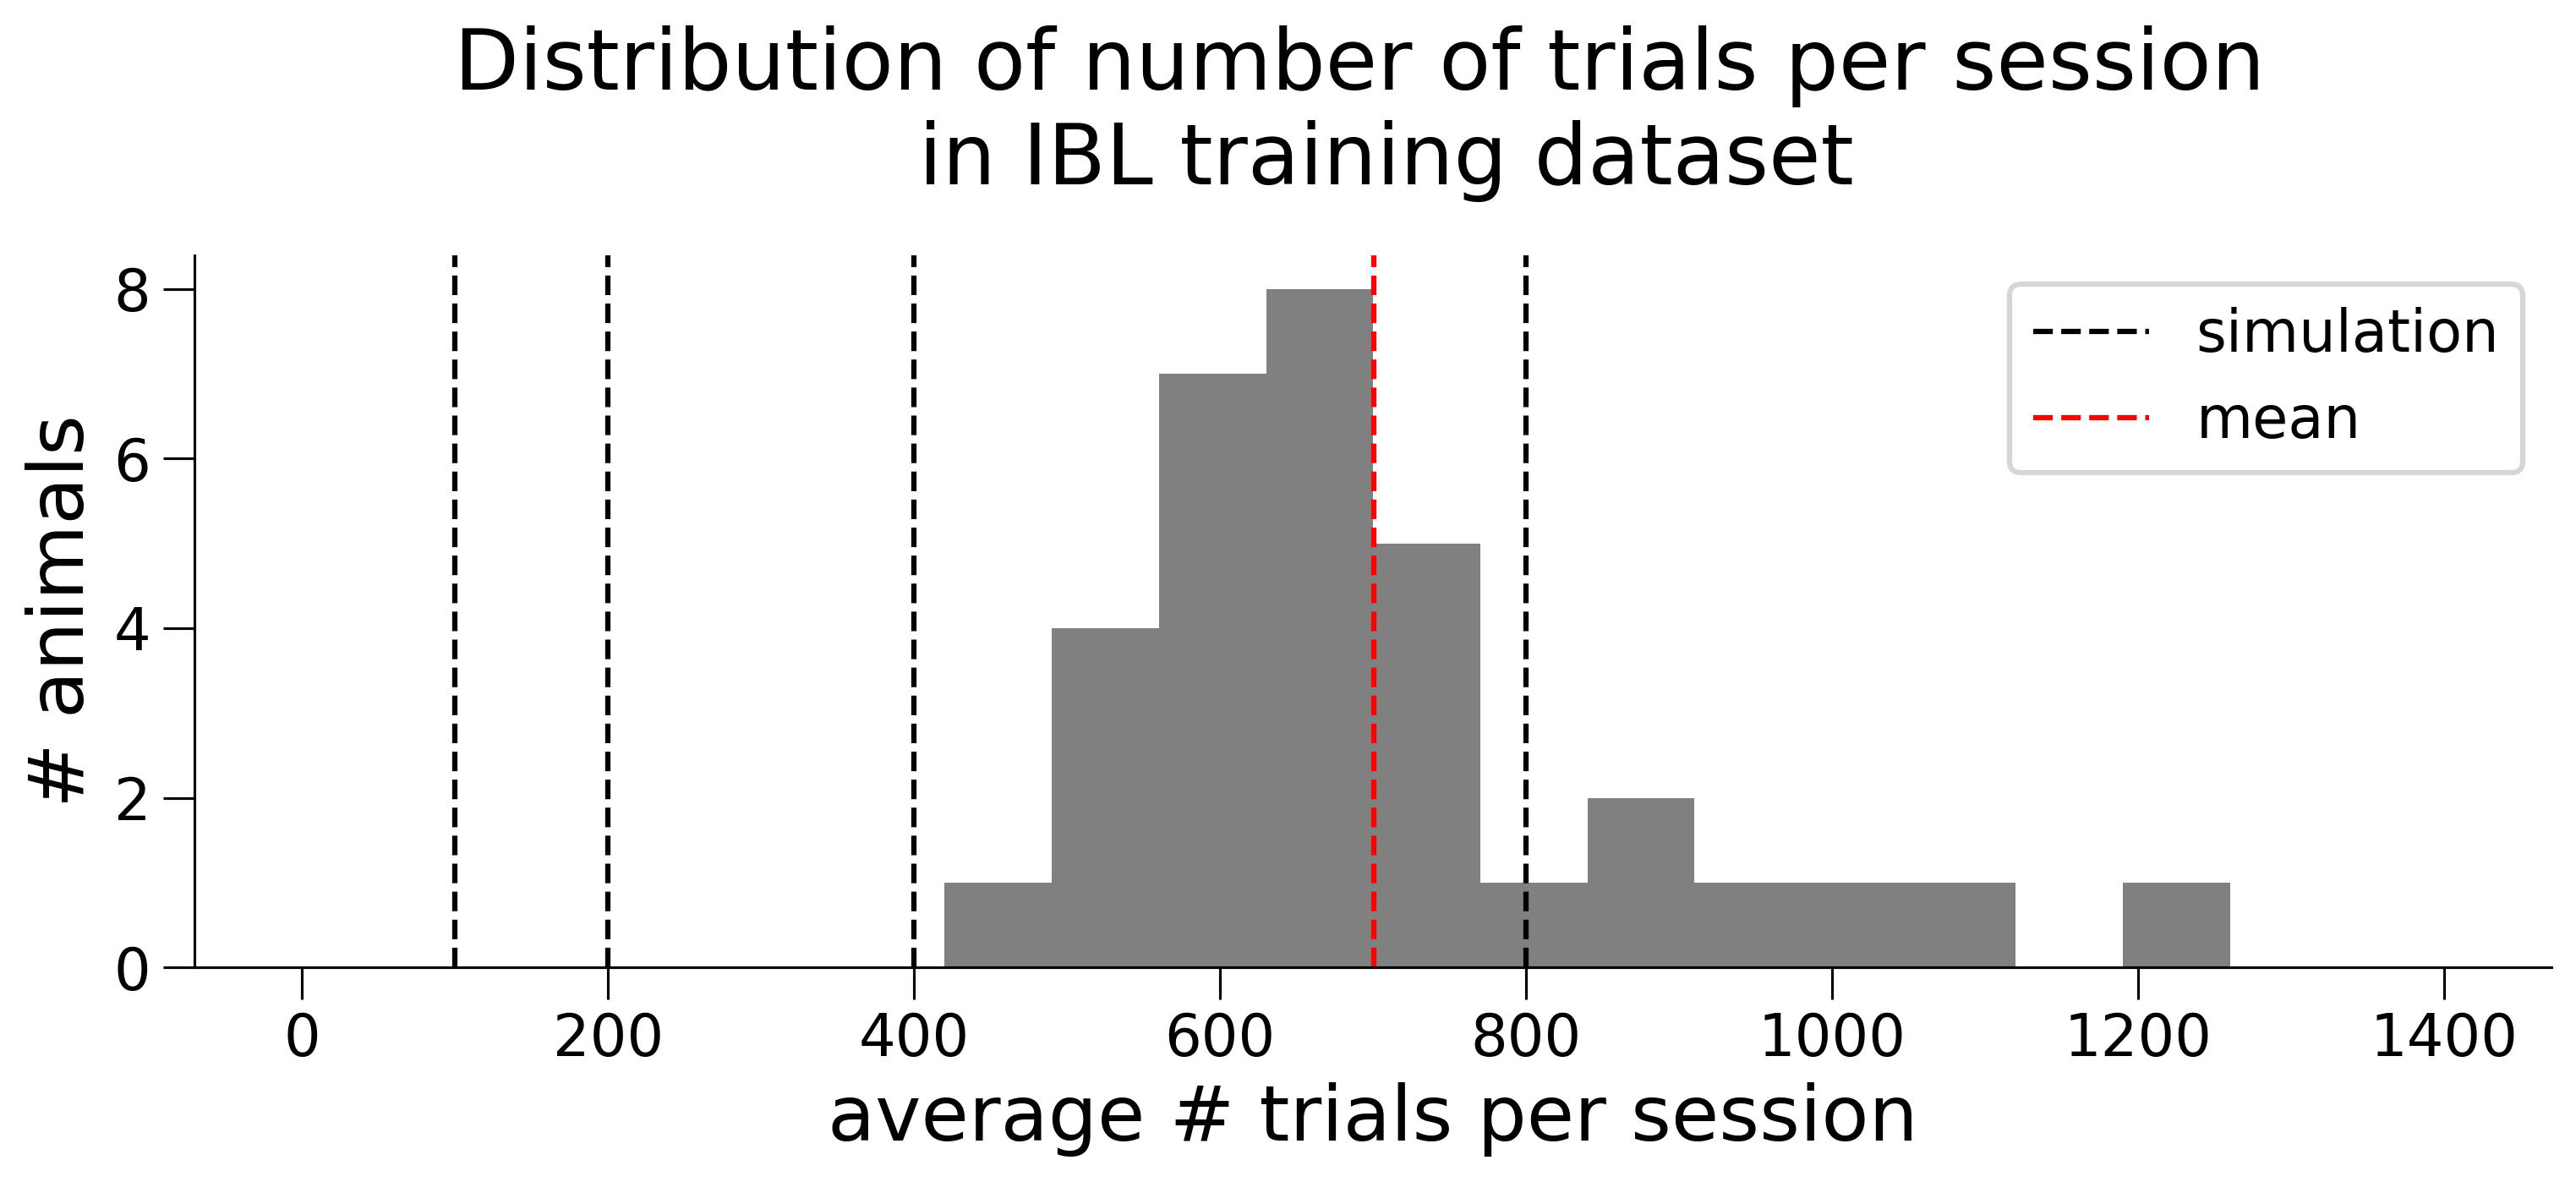

In [63]:
fig, axes = plt.subplots(1, figsize = (10.5,5), dpi=300)
fig.tight_layout()
axes.set_ylabel('# animals', size=22)
axes.set_xlabel('average # trials per session', size=22)
axes.set_title('Distribution of number of trials per session \n in IBL training dataset', size=24, pad=20)
# print(np.array(xAll).flatten().shape)
# range=(-4, 4),
axes.hist(np.array(trial_per_session_training), bins=20, range=(0, 1400), color='gray')
for sim in [100,200,400,800]:
    if sim == 100:
        axes.axvline(sim,linestyle='--',color='black', linewidth=1.5, label='simulation')
    else: 
        axes.axvline(sim,linestyle='--',color='black',linewidth=1.5)
axes.axvline(np.mean(trial_per_session_training),linewidth=1.5, linestyle='--',color='red', label='mean')
axes.legend()
axes.spines[['right', 'top']].set_visible(False)
axes.spines[['left', 'bottom']].set_linewidth(0.75)
axes.xaxis.set_tick_params(width=0.75)
axes.yaxis.set_tick_params(width=0.75)
fig.tight_layout()
plt.savefig(f'../figures/IBL_trials-per-session_during_learning.eps', format='eps', bbox_inches='tight', dpi=300)



# Simulations to show number of trials needed to recover good weights

In [3]:
sessions = [25, 50]
trials = [100,200,400,800]
Nsamples = 20

K = 3
D = 2
pTanh = 5
signedStimulus = True
sessStop = None

avg_model = np.load(f'../data_IBL/average_animals_fig4-5_best_parameters_dynamic.npz')
dynamicW = avg_model['bestAvgW']
dynamicP = avg_model['bestAvgP']
dynamicpi = np.ones((K))/K
truepi = np.ones((K))/K

subject = 'ibl_witten_15'
x, y, sessInd_old, correctSide, responseTimes = get_mouse_design(dfAll, subject, sessStop=None, signedStimulus=signedStimulus, pTanh=pTanh)
biasedBlockTrials, biasedBlockStartInd, biasedBlockSession, firstBlockSession = get_design_biased_blocks(dfAll, subject, sessInd_old, sessStop)
N = x.shape[0]
sess = len(sessInd_old)-1
x = x[:,:2] # only keeping bias and stimulus




In [4]:


standard_model = np.load(f'../data_IBL/all_animals/Best_allAnimals_standardGLMHMM_{K}-state_pTanh={pTanh}_signedStimulus={signedStimulus}.npz')
standardP = standard_model['P'][:50]
standardW = standard_model['W'][:50,:,:2]

print(dynamicW.shape)
print(standardW.shape)
print(standardP.shape)

(50, 3, 2, 2)
(50, 3, 2, 2)
(50, 3, 3)


In [5]:

print(dynamicP[0].sum(axis=1))
print(standardP[0].sum(axis=1))

# normalizing transition  matrix
for s in range(50):
    for j in range(K):
        dynamicP[s,j,:] = dynamicP[s,j,:] / dynamicP[s,j,:].sum()
        standardP[s,j,:] = standardP[s,j,:] / standardP[s,j,:].sum()

print(dynamicP[0].sum(axis=1))
print(standardP[0].sum(axis=1))

[0.99999783 0.99999754 0.9999979 ]
[0.99999992 0.99999957 0.99999945]
[1. 1. 1.]
[1. 1. 1.]


In [10]:
print(trueW[:,0,0,1])
print(W[:,0,0,1])

[ 0.07735593  0.07735593  0.07735593 ... -0.21478326 -0.21478326
 -0.21478326]
[ 0.08267056  0.08267056  0.08267056 ... -2.30852323 -2.30852323
 -2.30852323]


In [75]:
from matplotlib import pyplot as plt
import numpy as np
import pandas as pd
# from oneibl.onelight import ONE # only used for downloading data
# import wget
from utils import *
from plotting_utils import *
from analysis_utils import *
import dynamic_glmhmm
from pandas.errors import SettingWithCopyWarning
warnings.simplefilter(action="ignore", category=SettingWithCopyWarning)
import sys
import os
from io_utils import *

colormap = ['tab:purple','tab:pink','tab:cyan','yellowgreen', 'olive']
colorsStates = ['tab:orange','tab:blue','tab:green','tab:purple', 'tab:brown']
myFeatures = [['bias','stimulus', 'previous choice', 'previous reward'],['bias','contrast left','contrast right', 'previous choice', 'previous reward']]
ibl_data_path = '../data_IBL'
# dfAll = pd.read_csv(ibl_data_path + '/Ibl_processed.csv')
dfAll = pd.read_csv(ibl_data_path + '/IBL_processed_extra.csv')

sessions = [25, 50]
trials = [100,200,400,800]
Nsamples = 50

df = pd.DataFrame(columns=['init','K','signedStimulus', 'pTanh']) # in total z=0,399 inclusively
z = 0
for Nsess in sessions:
    for Ntrial in trials:
        for Nsample in range(Nsamples):
            df.loc[z, 'Nsess'] = Nsess
            df.loc[z, 'Ntrial'] = Ntrial
            df.loc[z, 'Nsample'] = Nsample
            z += 1

# read from cluster array in order to get parallelizations
idx = 100 #int(os.environ["SLURM_ARRAY_TASK_ID"])
Nsess = int(df.loc[idx,'Nsess'])
Ntrial = int(df.loc[idx,'Ntrial'])
# Ntrial = 800
Nsample = int(df.loc[idx, 'Nsample'])

K = 3
D = 2
pTanh = 5
signedStimulus = True
sessStop = None

avg_model = np.load(f'../data_IBL/average_animals_fig4-5_best_parameters_dynamic.npz')
dynamicW = avg_model['bestAvgW']
dynamicP = avg_model['bestAvgP']
dynamicpi = np.ones((K))/K
truepi = np.ones((K))/K

subject = 'ibl_witten_15'
x, y, sessInd_old, correctSide, responseTimes = get_mouse_design(dfAll, subject, sessStop=None, signedStimulus=signedStimulus, pTanh=pTanh)
biasedBlockTrials, biasedBlockStartInd, biasedBlockSession, firstBlockSession = get_design_biased_blocks(dfAll, subject, sessInd_old, sessStop)
N = x.shape[0]
sess = len(sessInd_old)-1
x = x[:,:2] # only keeping bias and stimulus

standard_model = np.load(f'../data_IBL/all_animals/Best_allAnimals_standardGLMHMM_{K}-state_pTanh={pTanh}_signedStimulus={signedStimulus}.npz')
standardP = standard_model['P'][:50]
standardW = standard_model['W'][:50,:,:2]

# normalizing transition  matrix
for s in range(50):
    for j in range(K):
        dynamicP[s,j,:] = dynamicP[s,j,:] / dynamicP[s,j,:].sum()
        standardP[s,j,:] = standardP[s,j,:] / standardP[s,j,:].sum()

sigmaList = [10**x for x in list(np.arange(-3,1,0.5,dtype=float))] + [10**x for x in list(np.arange(1,4,1,dtype=float))]
bestSigmaInd = 7 
bestSigma = sigmaList[bestSigmaInd-1]
print(bestSigma)
alphaList = [2*(10**x) for x in list(np.arange(-1,6,0.5,dtype=float))]
bestAlphaInd = 3  # Choosing best sigma index across animals
bestAlpha = alphaList[bestAlphaInd]
print(bestAlpha)
maxiter = 200

rng = np.random.default_rng(42)

truex = np.ones((Nsess * Ntrial, 2))
sessInd= [i * Ntrial for i in range(Nsess+1)]
for s in range(Nsess):
    truex[Ntrial * s : Ntrial * s + Ntrial, 1] = rng.choice(x[sessInd_old[s]:sessInd_old[s+1],1], size=Ntrial, replace=True).flatten()
        
N = truex.shape[0]
dGLM_HMM = dynamic_glmhmm.dynamic_GLMHMM(N,K,D,2)
trueW, trueP = reshape_parameters_session_to_trials(dynamicW[:Nsess+1], dynamicP[:Nsess+1], sessInd)
initW, initP = reshape_parameters_session_to_trials(standardW[:Nsess+1], standardP[:Nsess+1], sessInd)

# truey, truez = dGLM_HMM.simulate_data_given_x(truex, trueW, trueP, truepi, sessInd, seed=Nsample)

params = np.load(f'../simulations/dynamicGLMHMM_simulation_NatComms_sample={Nsample}_Nsess={Nsess}_Ntrial={Ntrial}.npz')
fitP = params['P']
fitW = params['W']
y = params['y']
z = params['z']
x = params['x']
trueW = params['trueW']
trueP = params['trueP']

# presentAll = np.ones((N))
# fitP, _, fitW, trainLl = dGLM_HMM.fit(truex, truey, presentAll, initP, truepi, initW, sigma=reshapeSigma(bestSigma, K, D), alpha=bestAlpha, A=standardP[0], sessInd=sessInd, maxIter=maxiter, tol=1e-3, model_type='dynamic',  L2penaltyW=0, priorDirP = None, fit_init_states=True)
# np.savez(f'../simulations/dynamicGLMHMM_simulation_NatComms_sample={Nsample}_Nsess={Nsess}_Ntrial={Ntrial}', P=fitP, W=fitW, y=truey, z=truez, x=truex, trueW=trueW, trueP=trueP)

print(Nsess)
print(Ntrial)

1.0
6.324555320336759
25
400


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


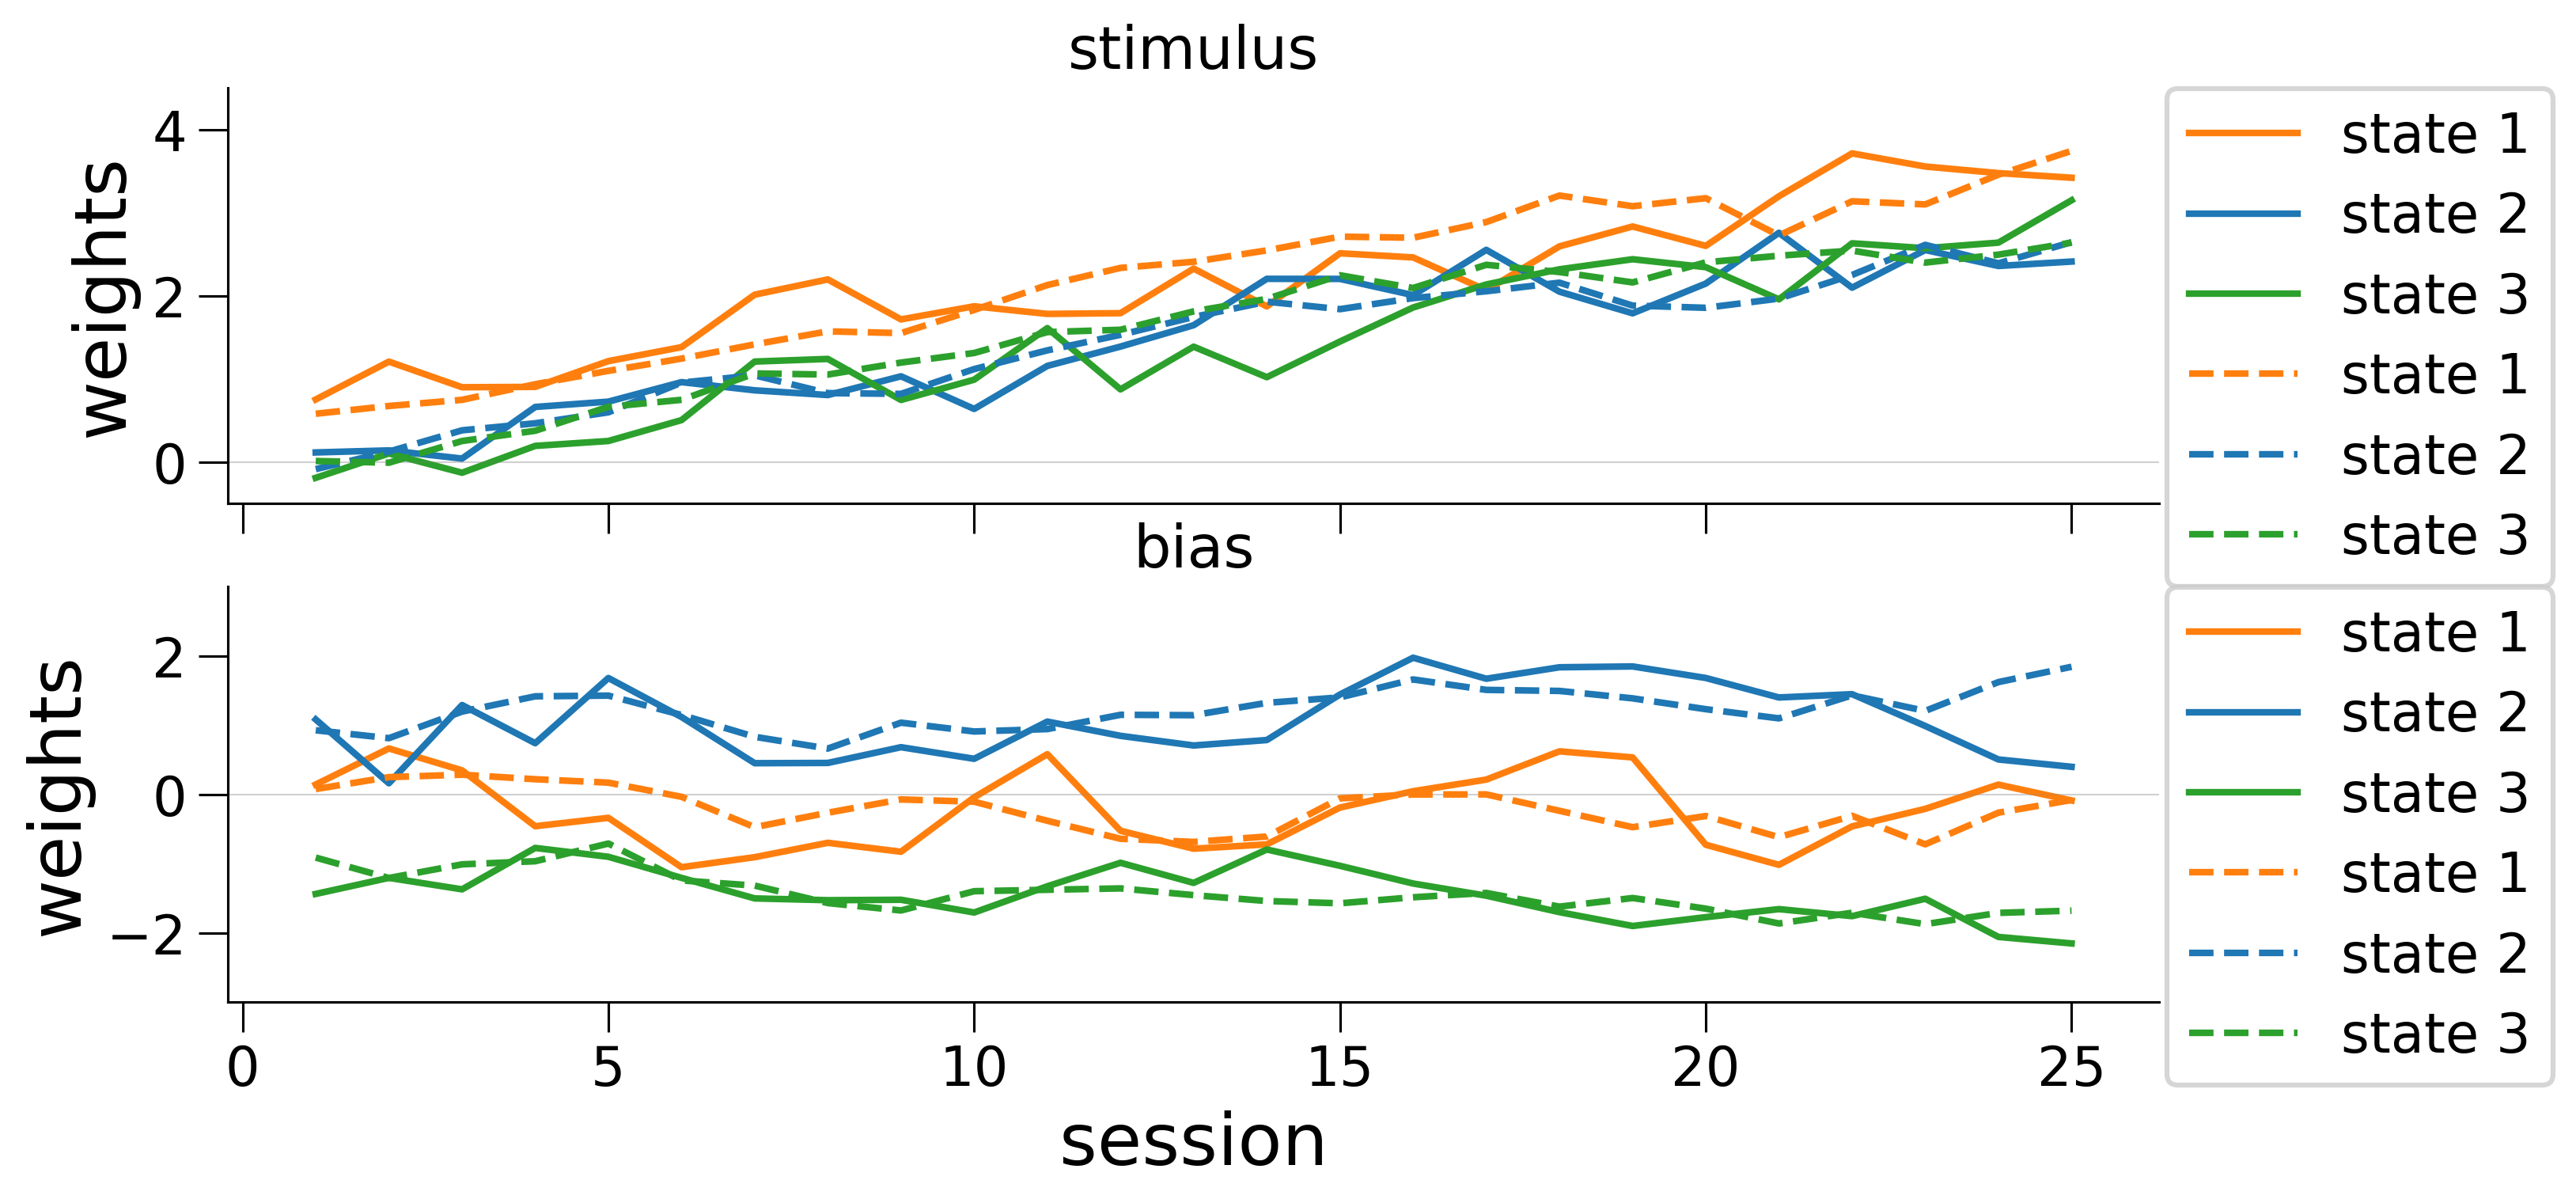

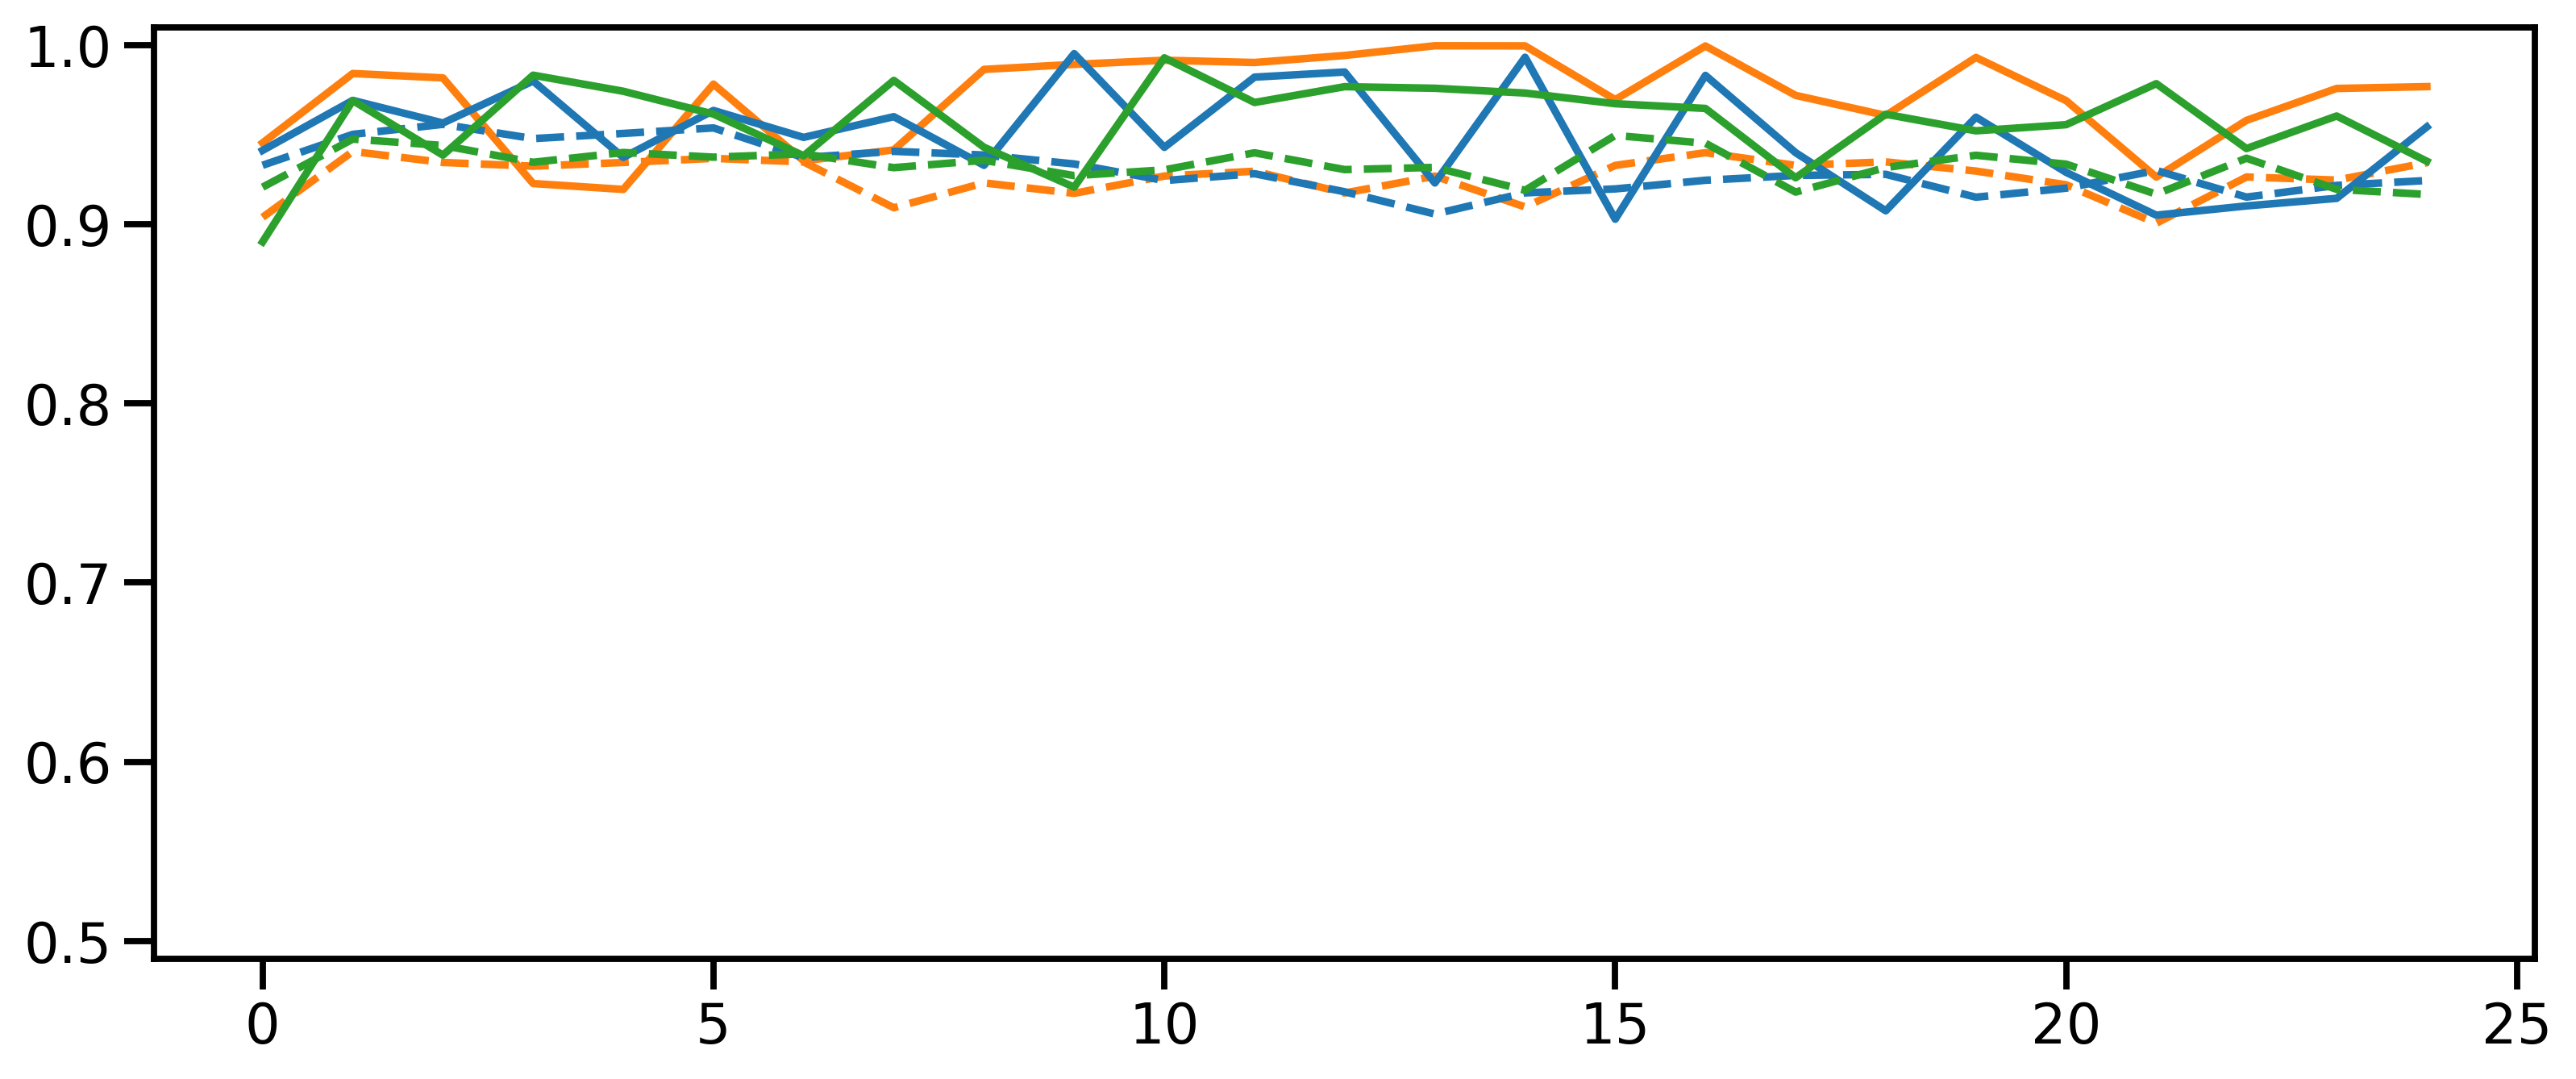

In [78]:
fig, axes = plt.subplots(2, 1,figsize=(10.5,5), sharex=True, dpi=300)
yLim=[[-0.5,4.5],[-3,3],[-3.7,3.7],[-3.7,3.7]]
plotting_weights_per_feature(fitW[:,:,[1,0],:], sessInd, axes, yLim=yLim, colors=colorsStates, labels=['stimulus','bias'], linewidth=2, linestyle='-', alpha=1, legend=True, sortedStateInd=None)
plotting_weights_per_feature(trueW[:,:,[1,0],:], sessInd, axes, yLim=yLim, colors=colorsStates, labels=['stimulus','bias'], linewidth=2, linestyle='--', alpha=1, legend=True, sortedStateInd=None)
# fig.tight_layout()
for k in range(2):
    axes[k].spines[['right', 'top']].set_visible(False)
    axes[k].spines[['left', 'bottom']].set_linewidth(0.75)
    axes[k].xaxis.set_tick_params(width=0.75)
    axes[k].yaxis.set_tick_params(width=0.75)
plt.savefig(f'../figures/Weight_recovery_simulation_400-trials.eps', format='eps', bbox_inches='tight', dpi=300)


fig, axes = plt.subplots(figsize=(12.7,5), sharex=True, dpi=300)
axes.set_ylim(0.49,1.01)
for k in range(K):  
    axes.plot(fitP[sessInd[:-1],k,k], '-',color=colorsStates[k])
    axes.plot(trueP[sessInd[:-1],k,k], '--',color=colorsStates[k])

# print(mse[:,-1,-1,-1,:].mean())

In [22]:
def compute_r2_weights(true_w, fitted_w):
    """
    true_w: S x K x D
    fitted_w: S x K x D
    returns: S array of R² values per session
    """
    S = true_w.shape[0]
    r2 = np.zeros(S)
    for s in range(S):
        true_flat = true_w[s].flatten()       # K*D values
        fitted_flat = fitted_w[s].flatten()
        ss_res = np.sum((true_flat - fitted_flat) ** 2)
        ss_tot = np.sum((true_flat - true_flat.mean()) ** 2)
        r2[s] = 1 - ss_res / ss_tot
    return r2

In [39]:
sigmaList = [10**x for x in list(np.arange(-3,1,0.5,dtype=float))] + [10**x for x in list(np.arange(1,4,1,dtype=float))]
bestSigmaInd = 7 
bestSigma = sigmaList[bestSigmaInd-1]
alphaList = [2*(10**x) for x in list(np.arange(-1,6,0.5,dtype=float))]
bestAlphaInd = 3  # Choosing best sigma index across animals
bestAlpha = alphaList[bestAlphaInd]
maxiter = 250

# sessions = [25]
# trials = [100]
# Nsamples = 1
sessions = [25]
trials = [100,200,400,800]
Nsamples = 50
Nsess = sessions[0]
mse = np.zeros((Nsess, len(trials), Nsamples))
r2_weights = np.zeros((Nsess, len(trials), Nsamples))
r2_transition= np.zeros((Nsess, len(trials), Nsamples))

for Ntrial in trials:
    idxtrial = trials.index(Ntrial)
    print(f'Ntrial {Ntrial}')
    for Nsample in range(Nsamples):    
        params = np.load(f'../simulations/dynamicGLMHMM_simulation_NatComms_sample={Nsample}_Nsess={Nsess}_Ntrial={Ntrial}.npz')
        P = params['P']
        W = params['W']
        y = params['y']
        z = params['z']
        x = params['x']
        trueW = params['trueW']
        trueP = params['trueP']

        sessInd = [i * Ntrial for i in range(Nsess+1)]

        mse[:Nsess,idxtrial,Nsample] = np.mean(np.square(W[sessInd[:-1],:,:,1] - trueW[sessInd[:-1],:,:,1]), axis=(1,2))   
        r2_weights[:Nsess,idxtrial,Nsample] = compute_r2_weights(trueW[sessInd[:-1],:,:,1], W[sessInd[:-1],:,:,1])
        r2_transition[:Nsess,idxtrial,Nsample] = compute_r2_weights(trueP[sessInd[:-1],:,:], P[sessInd[:-1],:,:])
            # fig, axes = plt.subplots(2, 1,figsize=(12.7,10.5), sharex=True, dpi=300)
            # yLim=[[-0.5,6.5],[-3.7,3.7],[-3.7,3.7],[-3.7,3.7]]
            # plotting_weights_per_feature(W[:,:,[1,0],:], sessInd, axes, yLim=yLim, colors=colorsStates, labels=['stimulus','bias'], linewidth=1, linestyle='-', alpha=1, legend=True, sortedStateInd=None)
            # plotting_weights_per_feature(trueW[:,:,[1,0],:], sessInd, axes, yLim=yLim, colors=colorsStates, labels=['stimulus','bias'], linewidth=1, linestyle='--', alpha=1, legend=True, sortedStateInd=None)


Ntrial 100
Ntrial 200
Ntrial 400
Ntrial 800


session 25
session 50


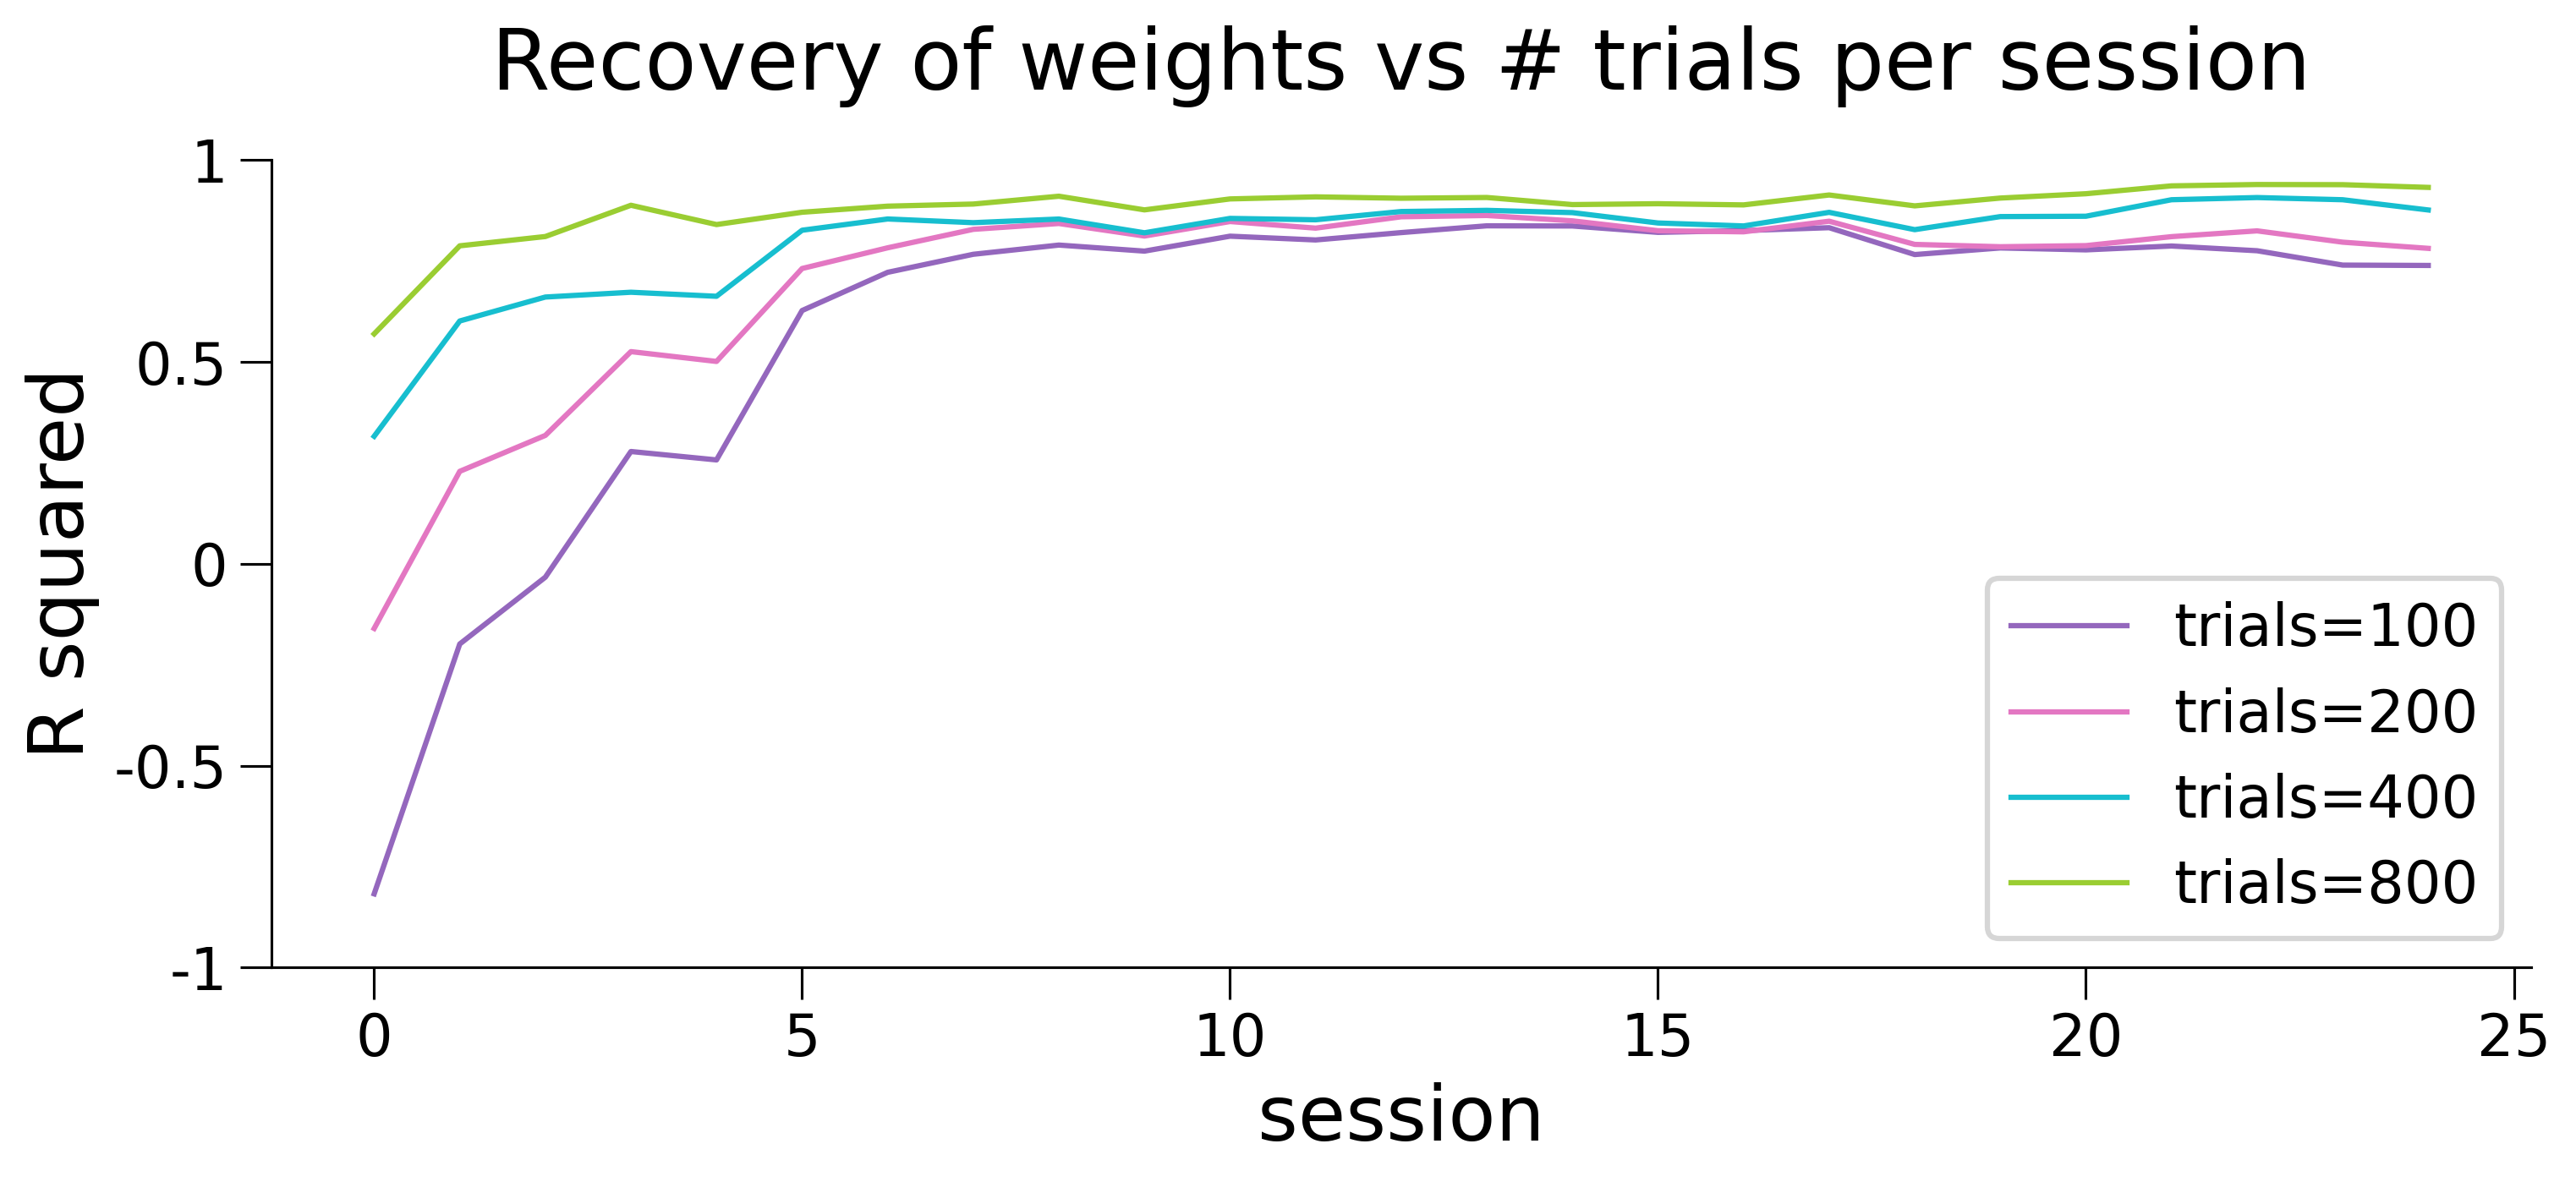

In [61]:
# mean_r2 = r2_weights.mean(axis=2)
# std_r2 = r2_weights.std(axis=2)

fig, axes = plt.subplots(1, figsize = (10.5,5), dpi=300)
for Nsess in sessions[:]:
    idxsess = sessions.index(Nsess)
    print(f'session {Nsess}')
    for Ntrial in trials:
        idxtrial = trials.index(Ntrial)
        if Nsess == 25:
            # axes.errorbar(range(Nsess), mean_r2, yerr=std_r2, fmt='-o', color=colormap[idxtrial], markersize=3, capsize=3)
            axes.plot(r2_weights[:Nsess,idxtrial,:].mean(axis=(1)),color=colormap[idxtrial], linewidth=1.5,label=f'trials={Ntrial}')

axes.set_ylim(-1,1)
axes.legend(loc='lower right')
axes.set_xlabel('session', size=22)
axes.set_ylabel('R squared', size=22)
axes.spines[['right', 'top']].set_visible(False)
axes.spines[['left', 'bottom']].set_linewidth(0.75)
axes.xaxis.set_tick_params(width=0.75)
axes.yaxis.set_tick_params(width=0.75)
axes.set_yticks([-1,-0.5,0,0.5,1],[-1,-0.5,0,0.5,1])
axes.set_title('Recovery of weights vs # trials per session', size=24, pad=20)
fig.tight_layout()
plt.savefig(f'../figures/Response_weights_simulations.pdf', format='pdf', bbox_inches='tight', dpi=300)

session 25
session 50


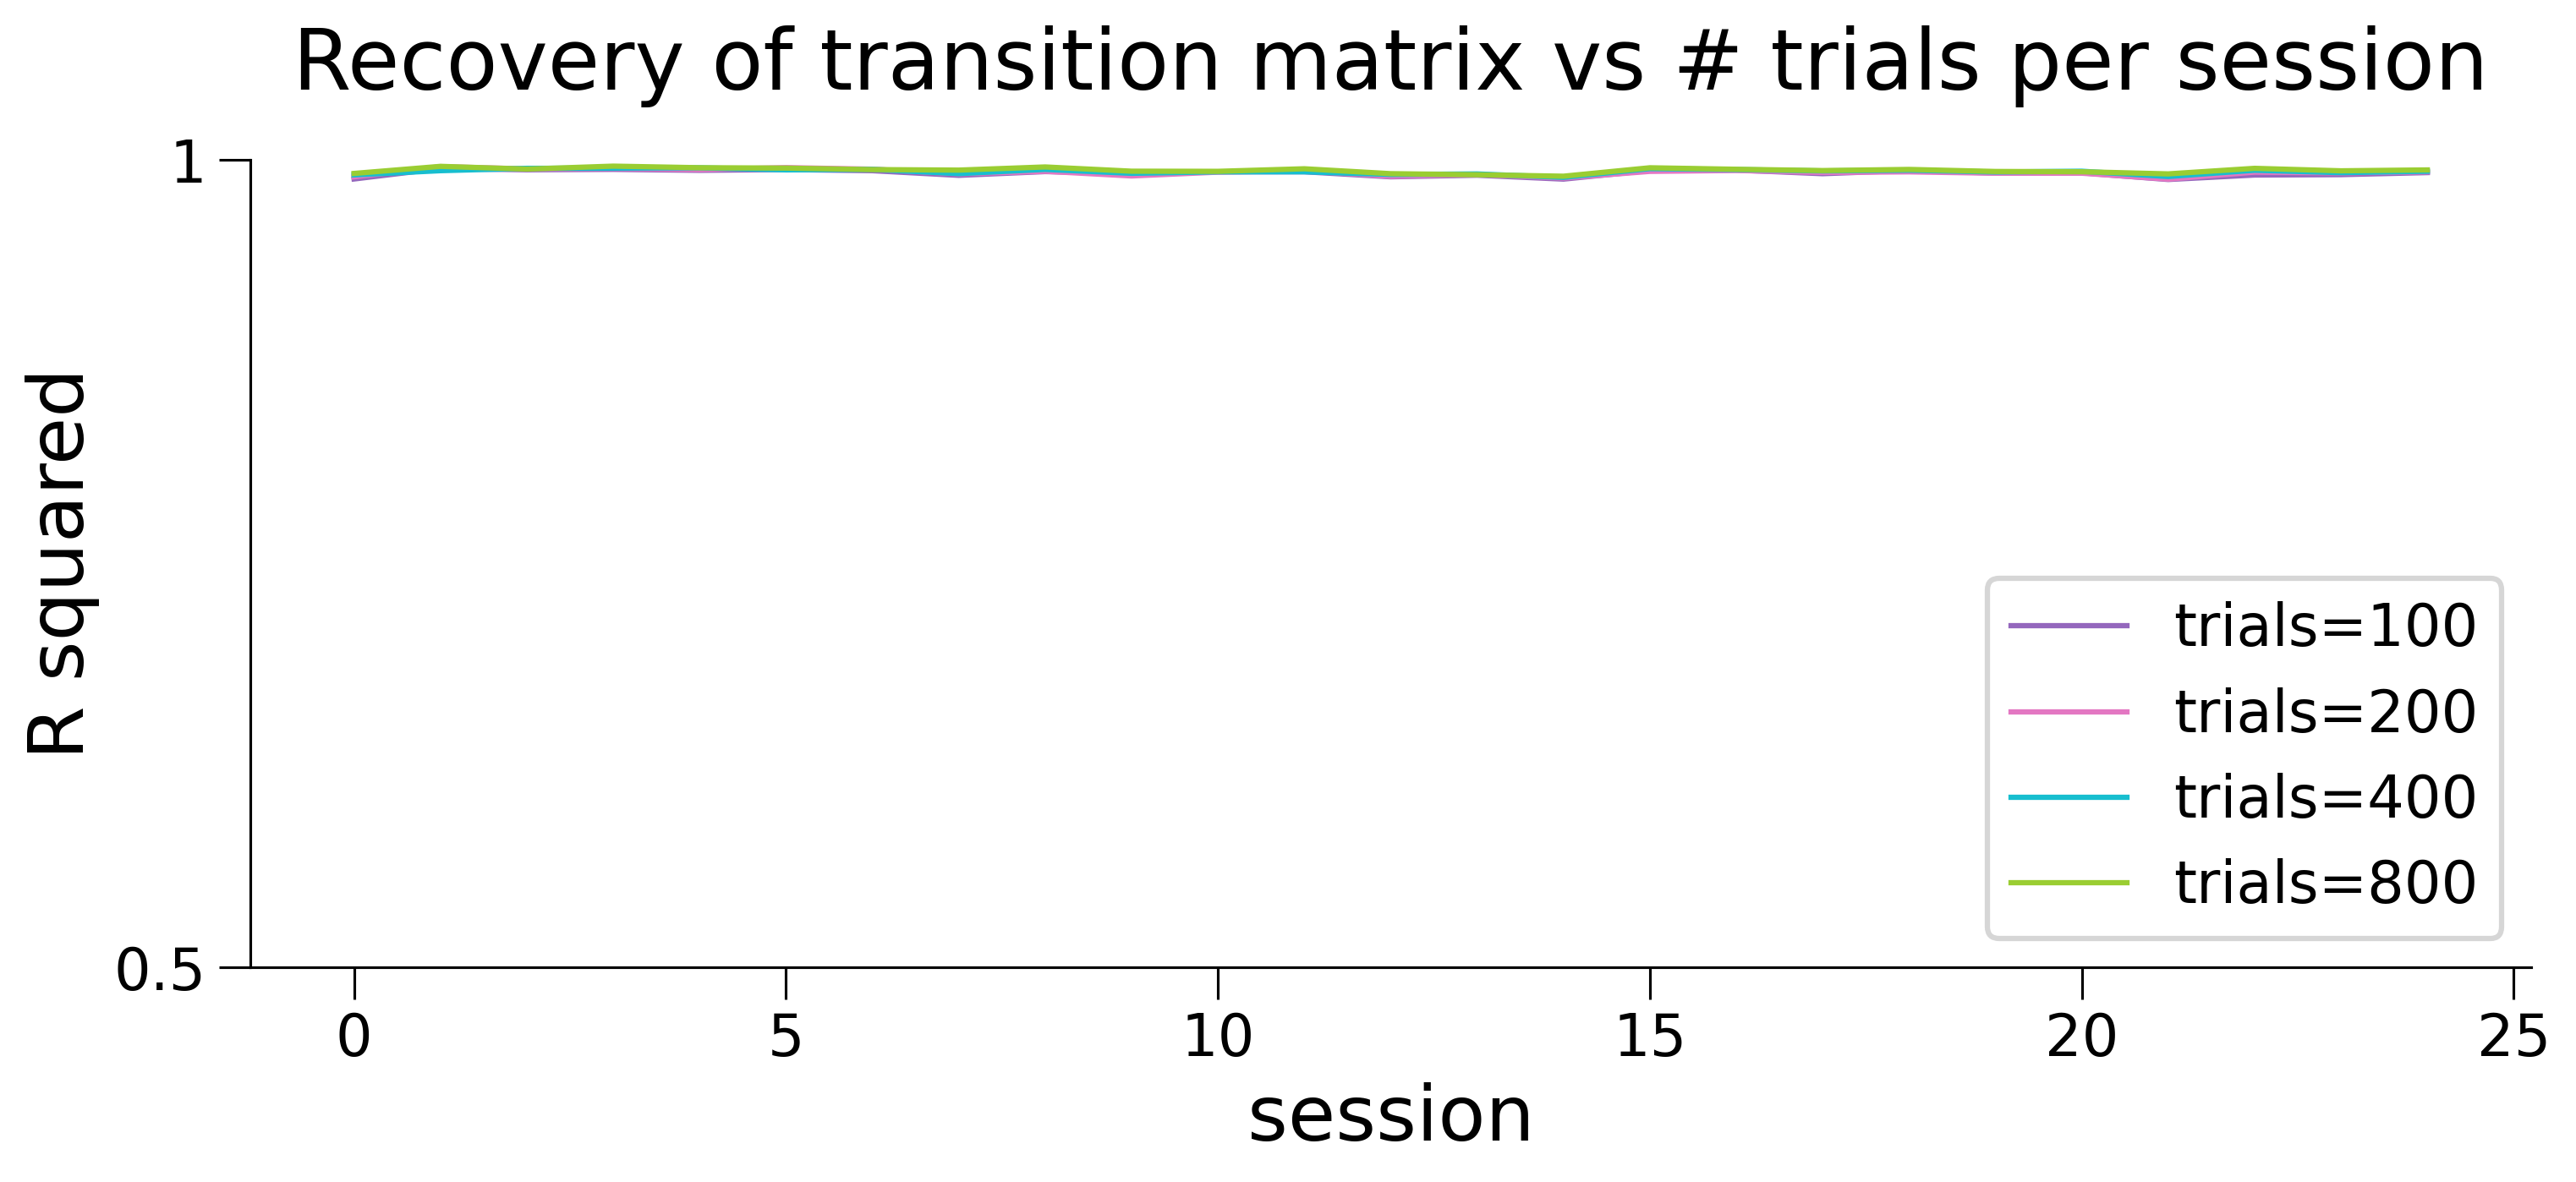

In [62]:
fig, axes = plt.subplots(1, figsize = (10.5,5), dpi=300)
for Nsess in sessions[:]:
    idxsess = sessions.index(Nsess)
    print(f'session {Nsess}')
    for Ntrial in trials:
        idxtrial = trials.index(Ntrial)
        if Nsess == 25:
            axes.plot(r2_transition[:Nsess,idxtrial,:].mean(axis=(1)),color=colormap[idxtrial], linewidth=1.5,label=f'trials={Ntrial}')
axes.set_ylim(0.5,1)
axes.legend(loc='lower right')
axes.set_xlabel('session', size=22)
axes.set_ylabel('R squared', size=22)
axes.spines[['right', 'top']].set_visible(False)
axes.spines[['left', 'bottom']].set_linewidth(0.75)
axes.xaxis.set_tick_params(width=0.75)
axes.yaxis.set_tick_params(width=0.75)
axes.set_yticks([0.5,1],[0.5,1])
axes.set_title('Recovery of transition matrix vs # trials per session', size=24, pad=20)
fig.tight_layout()
plt.savefig(f'../figures/Response_transitions_simulations.pdf', format='pdf', bbox_inches='tight', dpi=300)

session 25


/var/folders/w4/p225s7cd19n0j6tss7pdl21w0000gn/T/ipykernel_77111/2642108022.py:12: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes.legend()


Text(0.5, 1.0, 'Recovery of weights as a function of trial number')

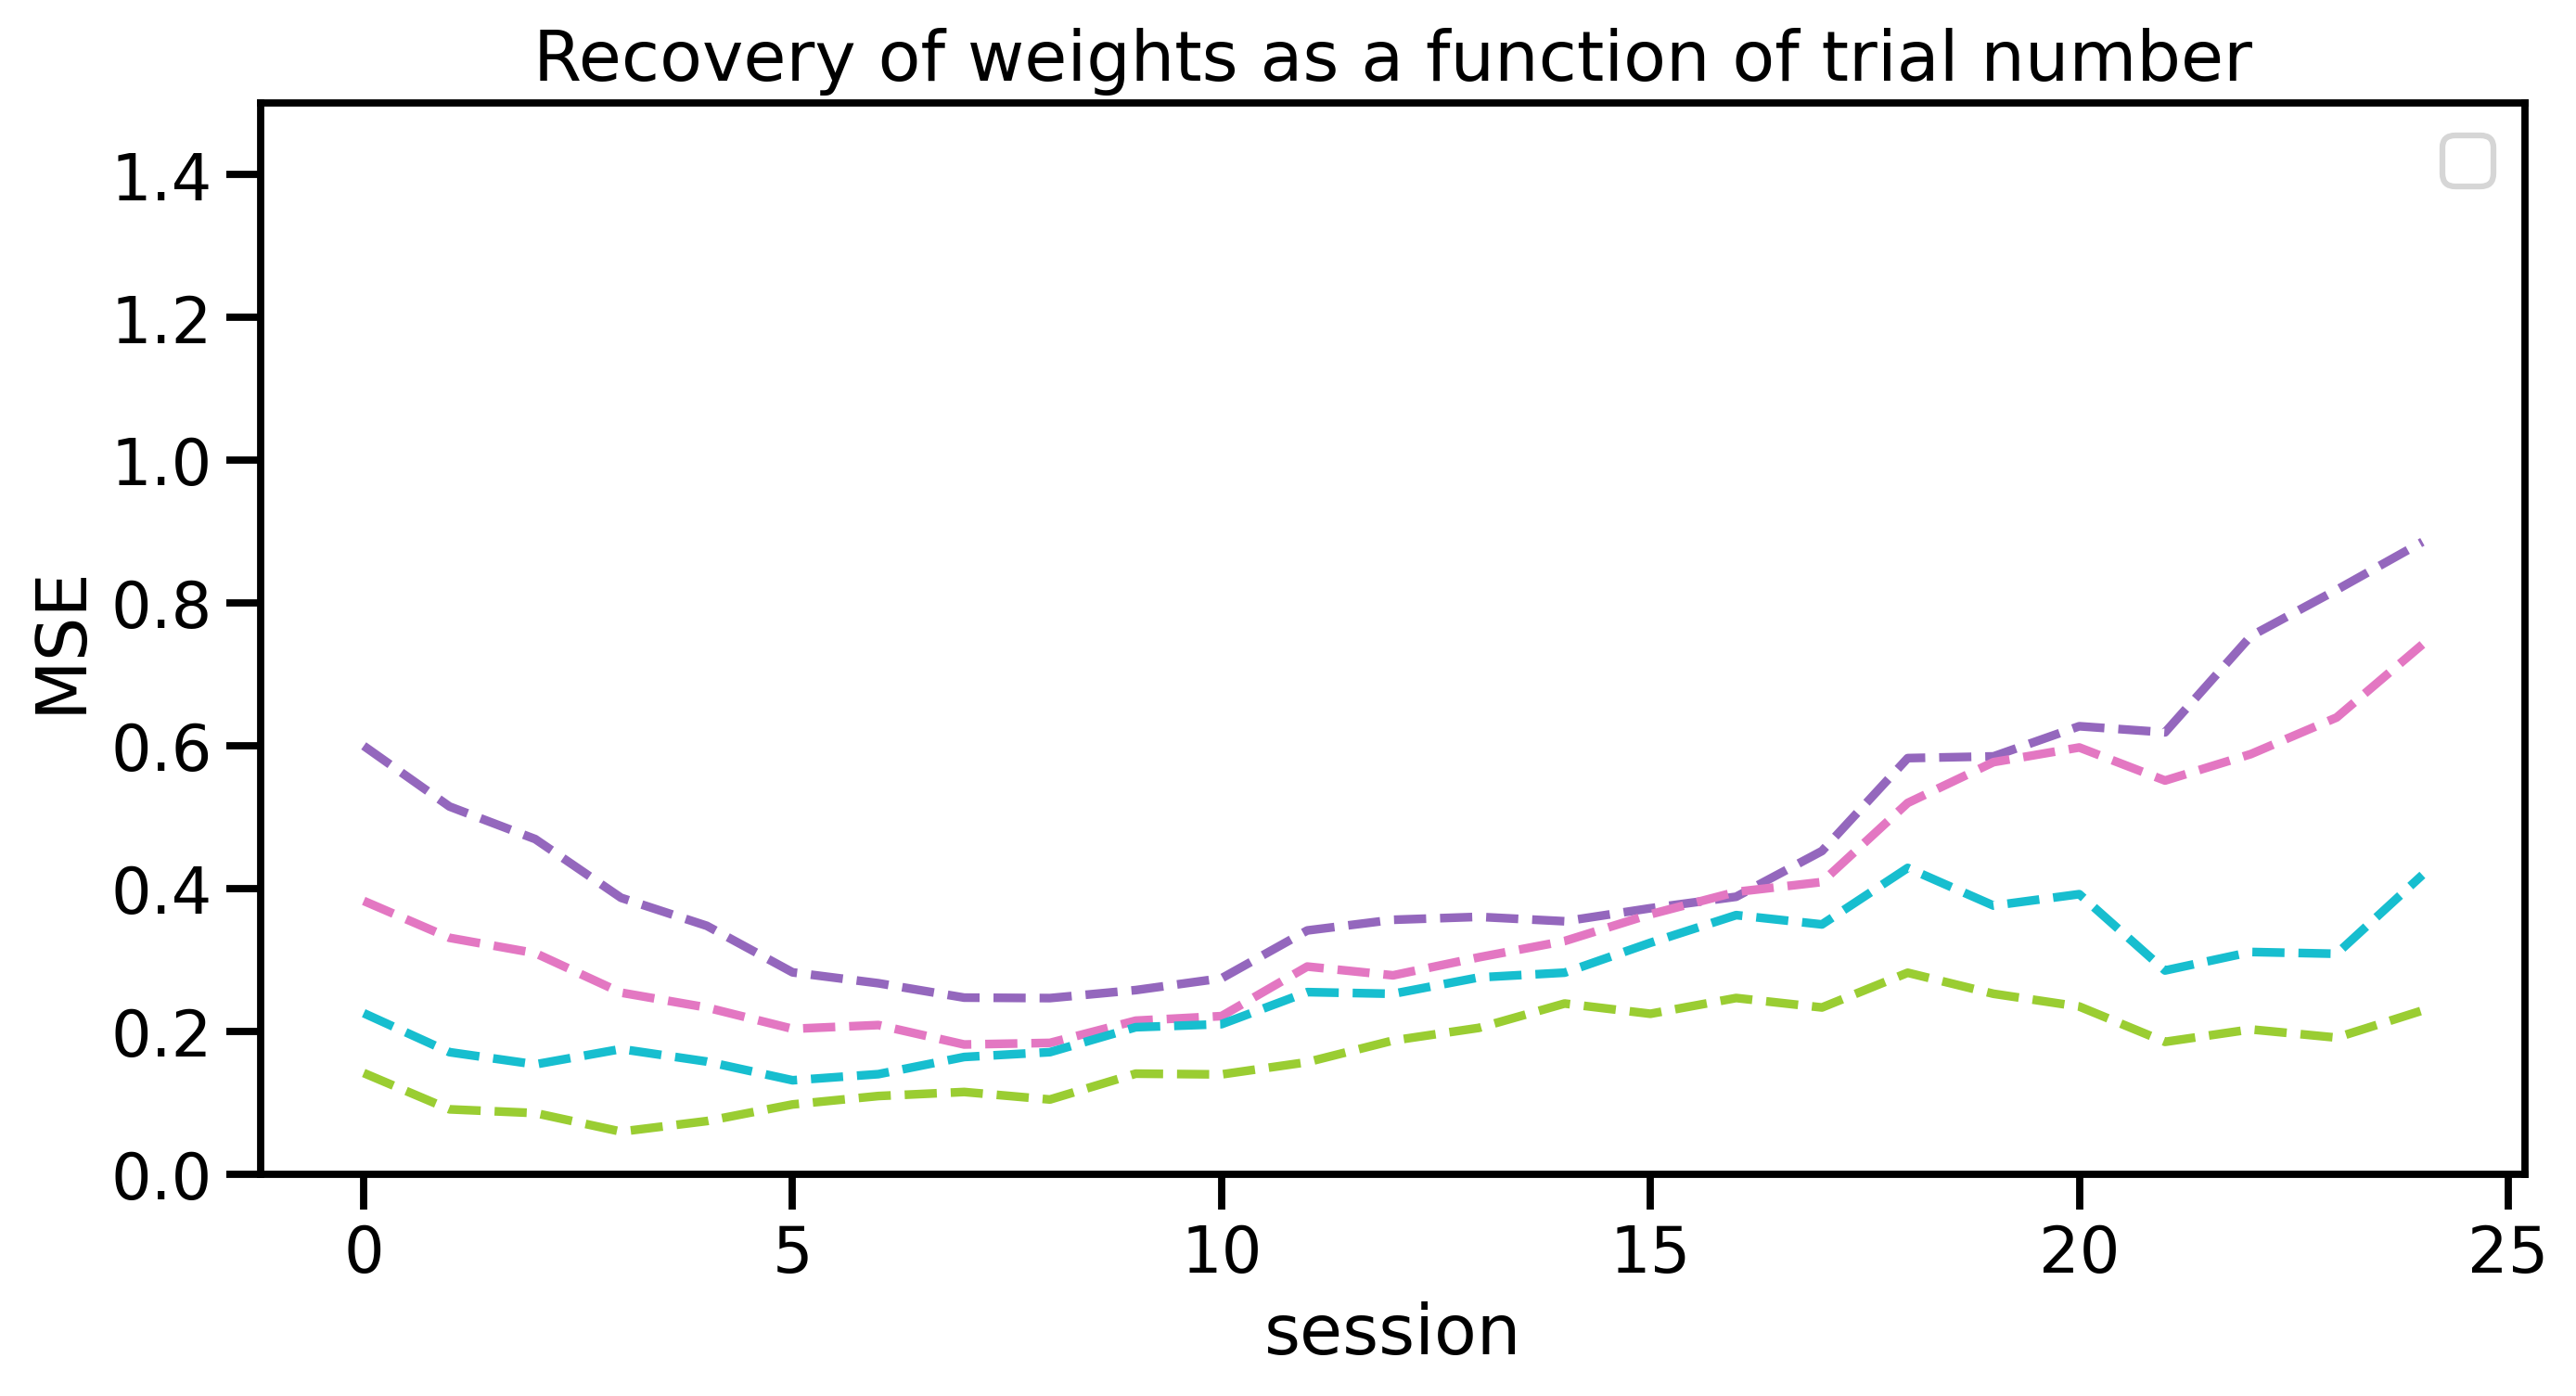

In [21]:
fig, axes = plt.subplots(1, figsize = (10.5,5), dpi=300)
for Nsess in sessions[:]:
    idxsess = sessions.index(Nsess)
    print(f'session {Nsess}')
    for Ntrial in trials:
        idxtrial = trials.index(Ntrial)
        if Nsess == 25:
            axes.plot(mse[:Nsess,idxsess,idxtrial,:,:].mean(axis=(1,2)), '--', color=colormap[idxtrial])
        else:
            axes.plot(mse[:Nsess,idxsess,idxtrial,:,:].mean(axis=(1,2)), color=colormap[idxtrial], label=f'trials={Ntrial}')
axes.set_ylim(0,1.5)
axes.legend()
axes.set_xlabel('session')
axes.set_ylabel('MSE')
axes.set_title('Recovery of weights as a function of trial number')

# Smoothing transition matrix across sessions

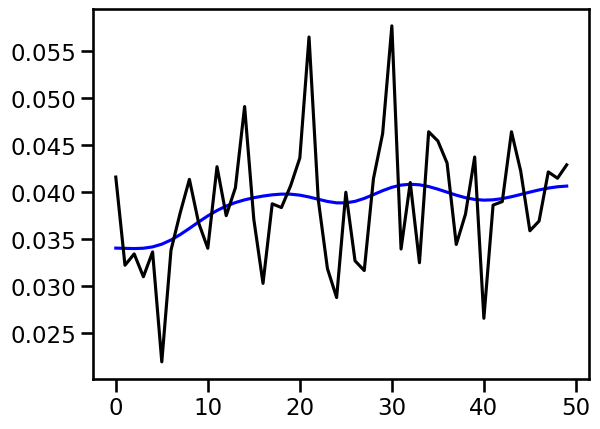

In [5]:
from scipy.ndimage import gaussian_filter1d
# x = np.random.randn(50)  # your vector
sigma = 4           # controls smoothing strength
x = dynamicP[:,0,1]
smoothed = gaussian_filter1d(x, sigma=sigma)
fig, axes = plt.subplots()
axes.plot(smoothed, color='blue')
axes.plot(x, color='black')

In [32]:
import dynamic_glmhmm
from scipy.ndimage import gaussian_filter1d
smoothList =[0] + [10**x for x in np.arange(0,2.5,0.5)]
# smoothList = [0,10]

# testAccuracyAll = np.zeros((K_max, len(subjectsAll), len(sigmaList)))
# # bestTestAccuracy = np.zeros((K_max, len(subjectsAll)))
dfAll = pd.read_csv(ibl_data_path + '/IBL_processed_extra.csv')
labChosen =  ['angelakilab','churchlandlab','wittenlab']
subjectsAll = []
for lab in labChosen:
    subjects = np.unique(dfAll[dfAll['lab'] == lab]['subject']).tolist()
    subjectsAll = subjectsAll + subjects
# missing data
if ('NYU-01' in subjectsAll):
    subjectsAll.remove('NYU-01')
if ('NYU-06' in subjectsAll):
    subjectsAll.remove('NYU-06')
if ('CSHL_007' in subjectsAll):
    subjectsAll.remove('CSHL_007')
if ('CSHL049' in subjectsAll):
    subjectsAll.remove('CSHL049')
if ('CSHL024' in subjectsAll):
    subjectsAll.remove('CSHL024')

# setting hyperparameters
sigmaList = [0] + [10**x for x in list(np.arange(-3,1,0.5,dtype=float))] + [10**x for x in list(np.arange(1,4,1,dtype=float))]
L2penaltyW = 0
priorDirP = [10,1]
maxiter = 300
splitFolds = 5
D = 4 # number of features
sessStop = None # last session to use in fitting
pTanh = 5 # tanh transformation
signedStimulus = True # signed stimulus contrast
fit_init_states = False # not fitting initial latent
K_max = 5 # maximum number of states
K = 3
bestSigmaInd = 8  # Choosing best sigma index across animals
bestAlphaInd = 3  # Choosing best sigma index across animals
truepi = np.ones((K))/K

# load fitted parameters from best partial and dynamic 3-state models
K = 3 # number of states to proceed with analysis
allP_best_dynamic = np.empty((len(subjectsAll)), dtype=object)
allW_best_dynamic = np.empty((len(subjectsAll)), dtype=object)

testLL = np.zeros((len(subjectsAll), splitFolds, len(smoothList)))
# testLlSessions = np.zers((len(subjectsAll), splitFolds, len(smoothList)))

for idx in range(0, len(subjectsAll)):
    subject=subjectsAll[idx]
    print(subject)
    x, y, sessInd, correctSide, _ = get_mouse_design(dfAll, subject, sessStop=sessStop, signedStimulus=signedStimulus, pTanh=pTanh)
    N = x.shape[0]
    sess = len(sessInd)-1

    dGLM_HMM = dynamic_glmhmm.dynamic_GLMHMM(N,K,D,2)

    presentTrain, presentTest = split_data(N, sessInd, folds=splitFolds, blocks=10, random_state=1)

    # parameters for best dynamic model
    for fold in range(splitFolds):
        data_dynamic = np.load(f'../data_IBL/{subject}/{subject}_dynamicGLMHMM_CV_{K}-state_fold={fold}_pTanh={pTanh}_L2penaltyW={L2penaltyW}_signedStimulus={signedStimulus}.npz')
        P_fold = data_dynamic['allP']
        W_fold = data_dynamic['allW']


        allW_best_dynamic, allP_best_dynamic = reshape_parameters_session_to_trials(W_fold[bestAlphaInd], P_fold[bestAlphaInd], sessInd)

        # fig, axes = plt.subplots()

        for smooth in smoothList:
            idxsmooth = smoothList.index(smooth)
            if smooth == 0:
                # evaluate 
                _, testLL[idx, fold, idxsmooth], _ = dGLM_HMM.evaluate(x, y, sessInd, presentTest[fold], allP_best_dynamic, truepi, allW_best_dynamic)
                # axes.plot(allP_best_dynamic[sessInd[:-1],0,0], color='black')
            else:
                # smooth with Gaussian Kernel (keeps distributions)
                smoothedP = gaussian_filter1d(allP_best_dynamic, sigma=smooth, axis=0)

                # evaluate 
                _, testLL[idx, fold, idxsmooth], _ = dGLM_HMM.evaluate(x, y, sessInd, presentTest[fold], smoothedP, truepi, allW_best_dynamic)

                # axes.plot(smoothedP[sessInd[:-1],0,0])
    
# axes.set_title('example best smoothing (sigma=10)')
# axes.set_ylabel('P(0->0)')
# axes.set_xlabel('sessions')

IBL-T1
IBL-T2
IBL-T3
IBL-T4
NYU-02
NYU-04
NYU-07
NYU-09
NYU-12
NYU-13
CSHL_001
CSHL_002
CSHL_003
CSHL_004
CSHL_005
CSHL_006
CSHL_008
CSHL_010
CSHL_012
CSHL_014
CSHL_015
ibl_witten_02
ibl_witten_03
ibl_witten_04
ibl_witten_05
ibl_witten_06
ibl_witten_07
ibl_witten_12
ibl_witten_13
ibl_witten_14
ibl_witten_15
ibl_witten_16


[-0.37615374 -0.37615268 -0.37614636 -0.37614576 -0.37620639 -0.37652779]


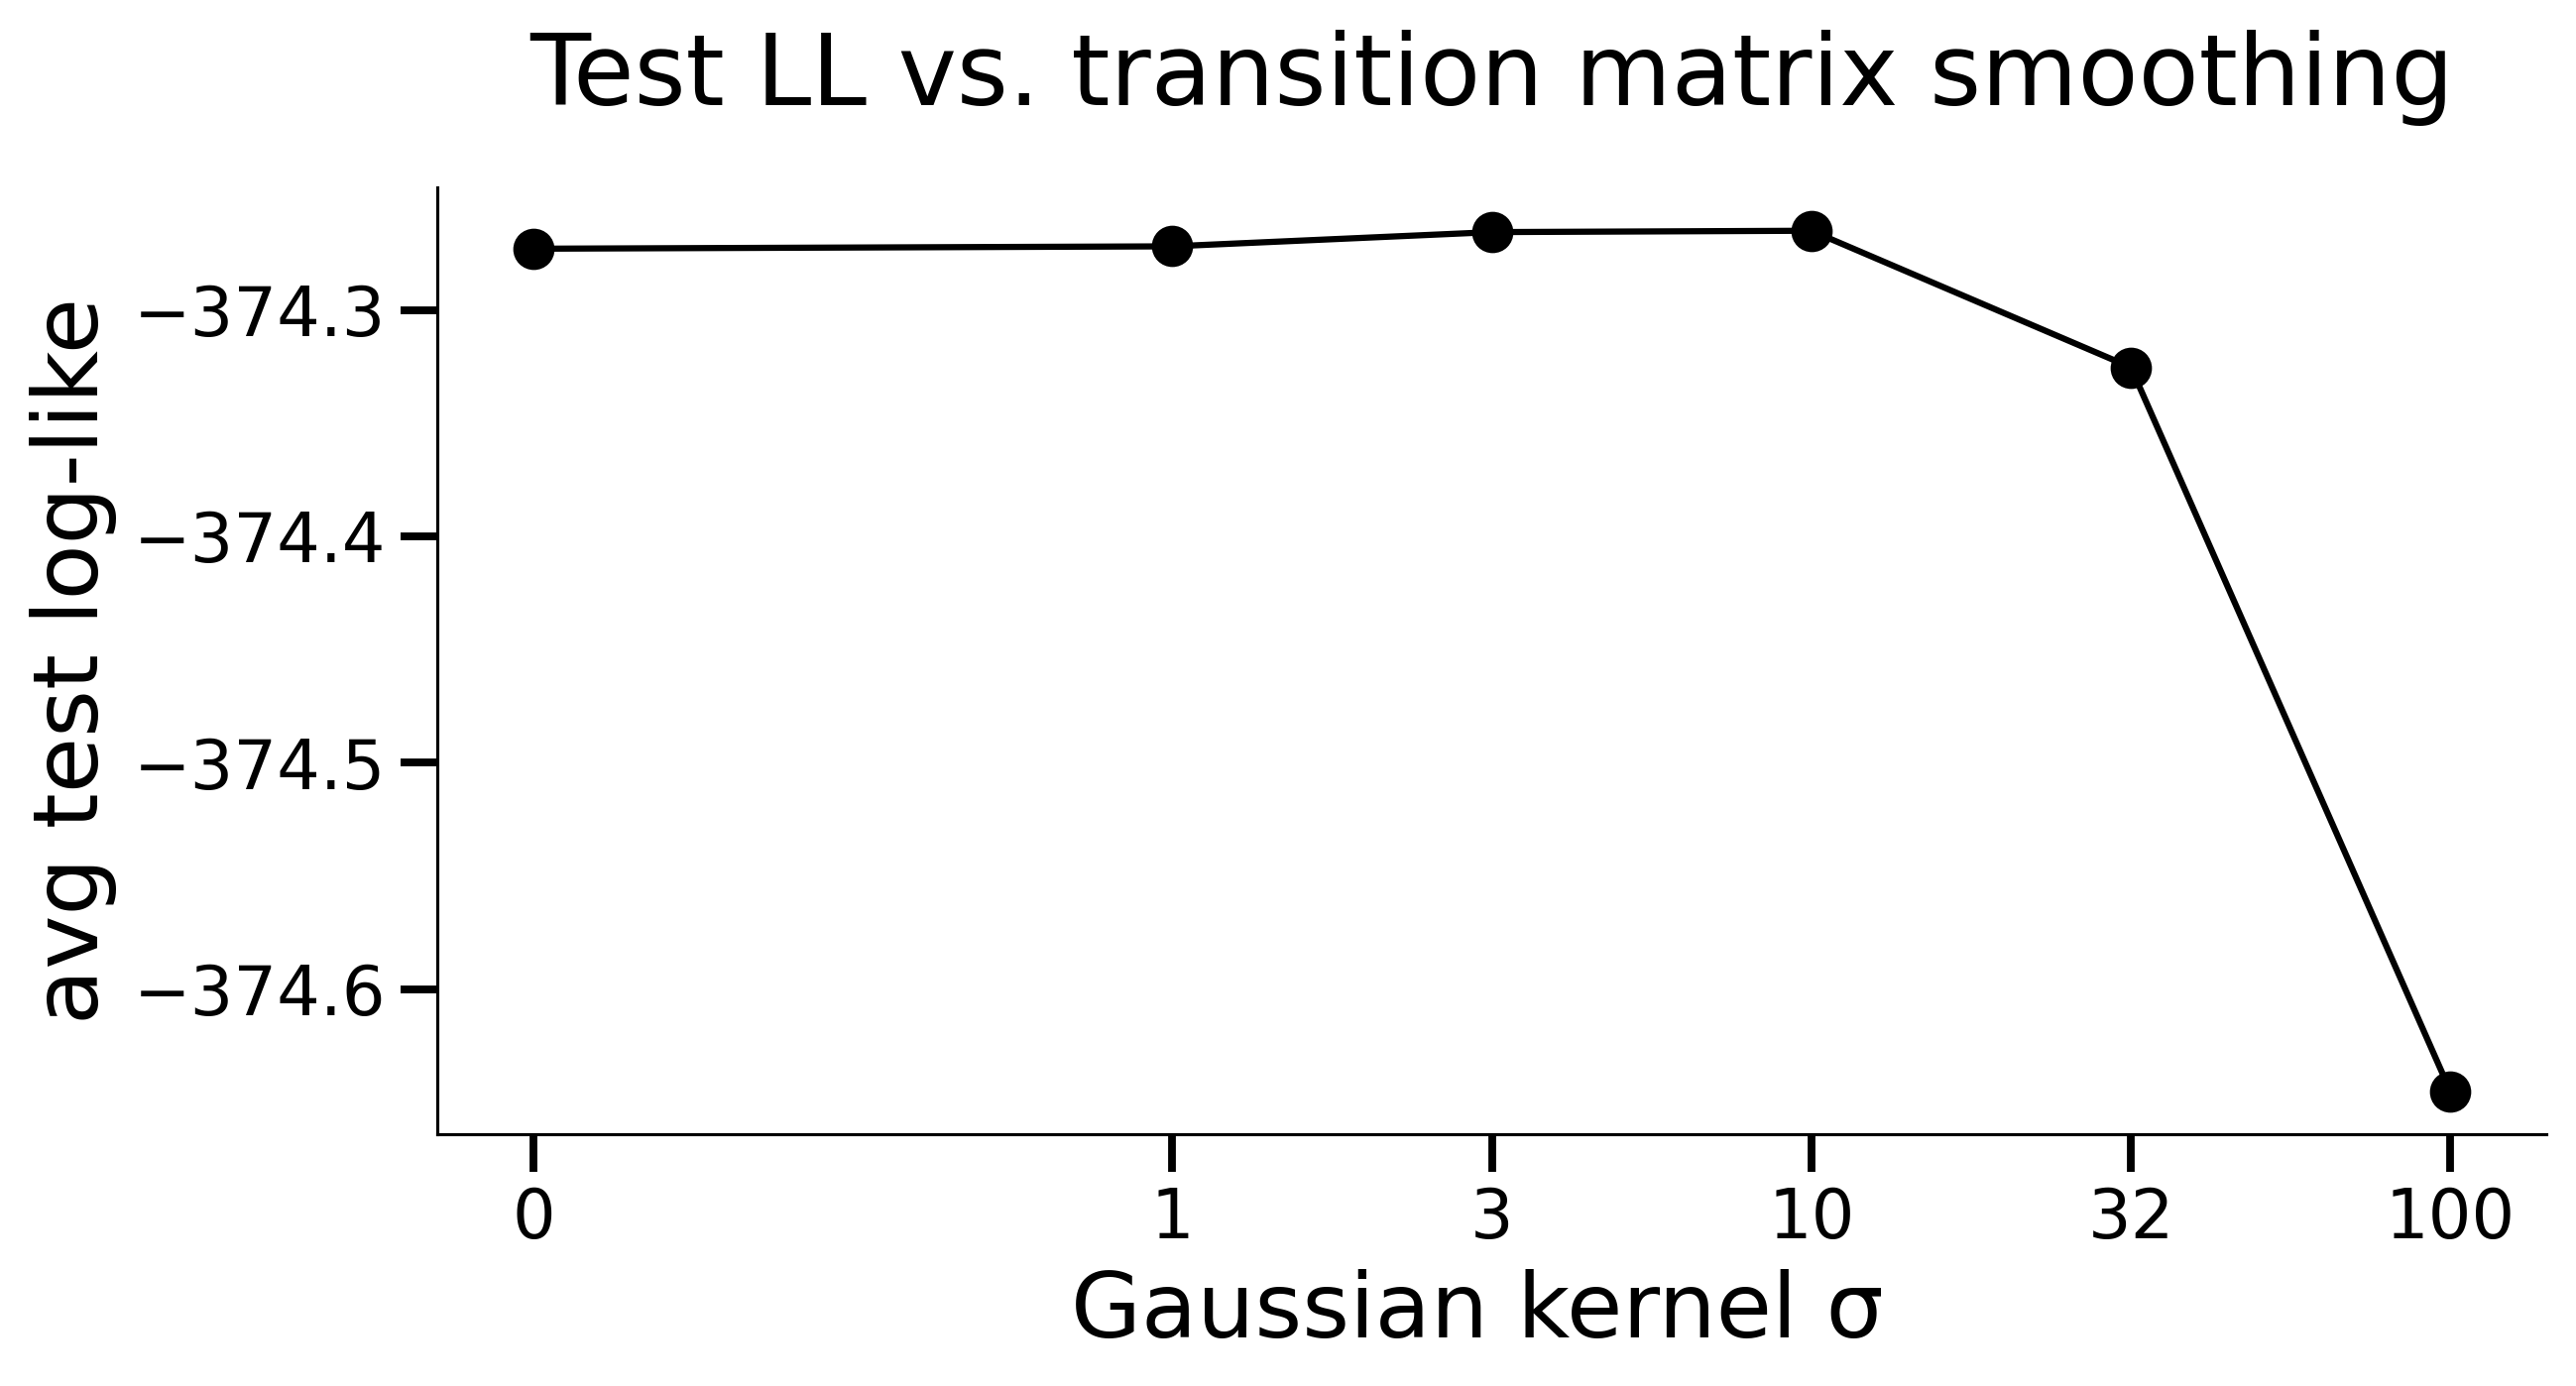

In [72]:
# print(testLL[0])
avg_session_length = 995
print(testLL[:,:].mean(axis=(0,1)))
# testLL = np.zeros((len(subjectsAll), splitFolds, len(smoothList)))
smoothList =[0] + [10**x for x in np.arange(0,2.5,0.5)]
fig, axes = plt.subplots(1, figsize = (9,5), dpi=300)
smoothList[0] += 10**(-1)
axes.plot(np.log10(smoothList), testLL[:,:].mean(axis=(0,1))*avg_session_length, '-o', linewidth=1.5, color='black')
# per_subject = testLL.mean(axis=1)  # average over folds → (subjects, smoothList)
# mean_ll = per_subject.mean(axis=0)
# std_ll = per_subject.std(axis=0)
# print(std_ll.shape)
# axes.errorbar(np.log10(smoothList), mean_ll, yerr=std_ll, fmt='-o', color='black', capsize=4)
smoothList2 = smoothList.copy()
smoothList2[0] = 0
axes.spines[['right', 'top']].set_visible(False)
axes.spines[['left', 'bottom']].set_linewidth(0.75)
axes.set_xticks(np.log10(smoothList), list(np.round(np.array(smoothList2),0).astype(int)))
axes.set_xlabel('Gaussian kernel σ ', size=22)
axes.set_ylabel('avg test log-like', size=22)
axes.set_title('Test LL vs. transition matrix smoothing', size=24, pad=20)
fig.tight_layout()
plt.savefig(f'../figures/Transition-matrix_smoothing_test_log-like.eps', format='pdf', bbox_inches='tight', dpi=300)

In [38]:
t, p = stats.ttest_rel(testLL[:,:,3].flatten(), testLL[:,:,0].flatten(), nan_policy='omit', alternative='greater')
print(f"t = {t:.3f}, p = {p:.3g}")

stat, p = stats.wilcoxon(testLL[:,:,3].flatten(), testLL[:,:,0].flatten(), nan_policy='omit', alternative='greater')
print(f"stat = {stat:.3f}, p = {p:.3g}")


t = 0.914, p = 0.181
stat = 6671.000, p = 0.347


ibl_witten_12


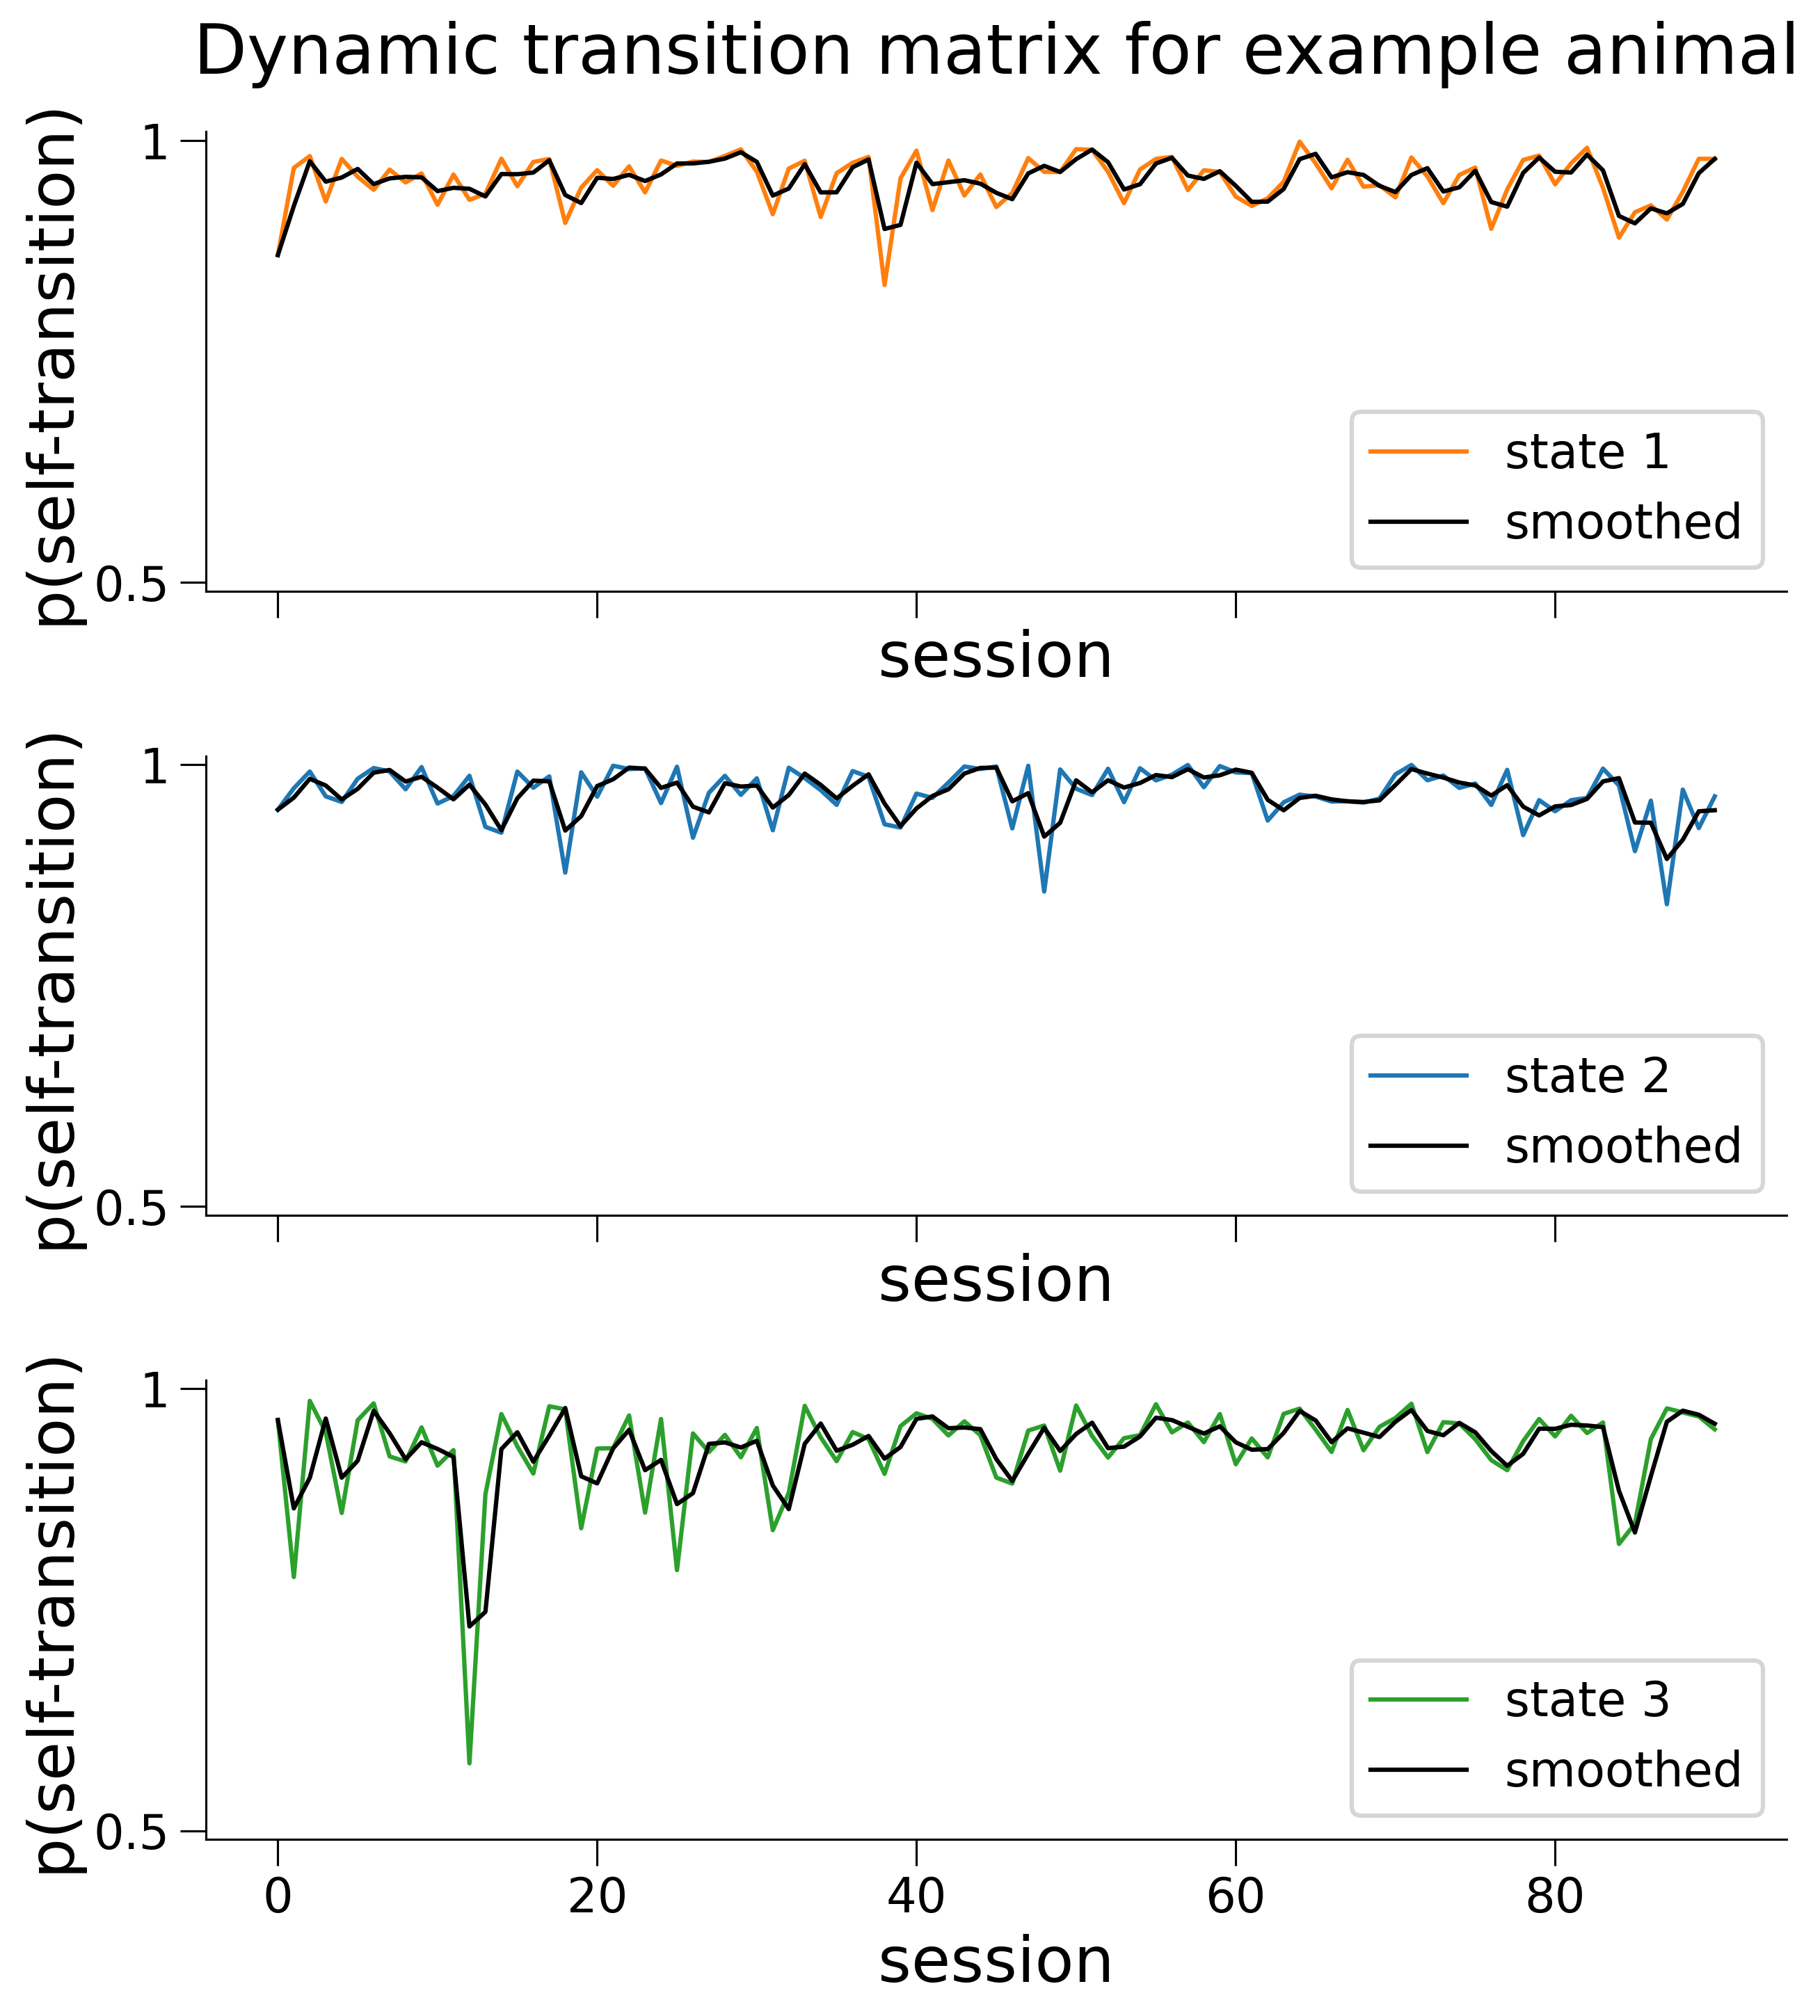

In [73]:
subject='ibl_witten_12'
print(subject)
x, y, sessInd, correctSide, _ = get_mouse_design(dfAll, subject, sessStop=sessStop, signedStimulus=signedStimulus, pTanh=pTanh)
N = x.shape[0]
sess = len(sessInd)-1
prsentAll = np.ones((N)).astype(int)

dGLM_HMM = dynamic_glmhmm.dynamic_GLMHMM(N,K,D,2)

# parameters for best dynamic model
fold = 0
data_dynamic = np.load(f'../data_IBL/{subject}/{subject}_dynamicGLMHMM_CV_{K}-state_fold={fold}_pTanh={pTanh}_L2penaltyW={L2penaltyW}_signedStimulus={signedStimulus}.npz')
P_fold = data_dynamic['allP']
W_fold = data_dynamic['allW']
allW_best_dynamic, allP_best_dynamic = reshape_parameters_session_to_trials(W_fold[bestAlphaInd], P_fold[bestAlphaInd], sessInd)

smooth = smoothList[2]
 # smooth with Gaussian Kernel (keeps distributions)
smoothedP = gaussian_filter1d(allP_best_dynamic, sigma=smooth, axis=0)

fig, axes = plt.subplots(3, 1, figsize = (9,10), dpi=300, sharex=True)
for k in range(K):
    axes[k].plot(allP_best_dynamic[sessInd[:-1],k,k], color=colorsStates[k], linewidth=1.5, label=f'state {k+1}')
    axes[k].plot(smoothedP[sessInd[:-1],k,k], color='black', linewidth=1.5, label='smoothed')
    axes[k].set_ylim(0.49,1.01)
    axes[k].set_yticks([0.5,1],[0.5,1])
    axes[k].set_ylabel('p(self-transition)', size=22)
    axes[k].set_xlabel('session', size=22)
    axes[k].legend(loc='lower right')
    axes[k].spines[['right', 'top']].set_visible(False)
    axes[k].spines[['left', 'bottom']].set_linewidth(0.75)
    axes[k].xaxis.set_tick_params(width=0.75)
    axes[k].yaxis.set_tick_params(width=0.75)
# axes.set_title('example best smoothing (sigma=10)')
axes[0].set_title('Dynamic transition matrix for example animal', size=24, pad=20)
fig.tight_layout()
plt.savefig(f'../figures/Transition-matrix_smoothing_example_{subject}.eps', format='pdf', bbox_inches='tight', dpi=300)

In [11]:
import dynamic_glmhmm
from scipy.ndimage import gaussian_filter1d
smoothList =[0] + [10**x for x in np.arange(0,2.5,0.5)]
# smoothList = [0,10]

# testAccuracyAll = np.zeros((K_max, len(subjectsAll), len(sigmaList)))
# # bestTestAccuracy = np.zeros((K_max, len(subjectsAll)))
dfAll = pd.read_csv(ibl_data_path + '/IBL_processed_extra.csv')
labChosen =  ['angelakilab','churchlandlab','wittenlab']
subjectsAll = []
for lab in labChosen:
    subjects = np.unique(dfAll[dfAll['lab'] == lab]['subject']).tolist()
    subjectsAll = subjectsAll + subjects
# missing data
if ('NYU-01' in subjectsAll):
    subjectsAll.remove('NYU-01')
if ('NYU-06' in subjectsAll):
    subjectsAll.remove('NYU-06')
if ('CSHL_007' in subjectsAll):
    subjectsAll.remove('CSHL_007')
if ('CSHL049' in subjectsAll):
    subjectsAll.remove('CSHL049')
if ('CSHL024' in subjectsAll):
    subjectsAll.remove('CSHL024')

# setting hyperparameters
sigmaList = [0] + [10**x for x in list(np.arange(-3,1,0.5,dtype=float))] + [10**x for x in list(np.arange(1,4,1,dtype=float))]
L2penaltyW = 0
priorDirP = [10,1]
maxiter = 300
splitFolds = 5
D = 4 # number of features
sessStop = None # last session to use in fitting
pTanh = 5 # tanh transformation
signedStimulus = True # signed stimulus contrast
fit_init_states = False # not fitting initial latent
K_max = 5 # maximum number of states
K = 3
bestSigmaInd = 8  # Choosing best sigma index across animals
bestAlphaInd = 3  # Choosing best sigma index across animals
truepi = np.ones((K))/K

# load fitted parameters from best partial and dynamic 3-state models
K = 3 # number of states to proceed with analysis
allP_best_dynamic = np.empty((len(subjectsAll)), dtype=object)
allW_best_dynamic = np.empty((len(subjectsAll)), dtype=object)

LL = np.zeros((len(subjectsAll), len(smoothList)))
# testLlSessions = np.zers((len(subjectsAll), splitFolds, len(smoothList)))

for idx in range(0, len(subjectsAll)):
    subject=subjectsAll[idx]
    print(subject)
    x, y, sessInd, correctSide, _ = get_mouse_design(dfAll, subject, sessStop=sessStop, signedStimulus=signedStimulus, pTanh=pTanh)
    N = x.shape[0]
    sess = len(sessInd)-1
    prsentAll = np.ones((N)).astype(int)

    dGLM_HMM = dynamic_glmhmm.dynamic_GLMHMM(N,K,D,2)

    # parameters for best dynamic model
    P_fold = np.empty((splitFolds), dtype=object)
    W_fold = np.empty((splitFolds), dtype=object)
    for fold in range(splitFolds):
        data_dynamic = np.load(f'../data_IBL/{subject}/{subject}_dynamicGLMHMM_CV_{K}-state_fold={fold}_pTanh={pTanh}_L2penaltyW={L2penaltyW}_signedStimulus={signedStimulus}.npz')
        P_fold[fold] = data_dynamic['allP']
        W_fold[fold] = data_dynamic['allW']
    allW_best_dynamic, allP_best_dynamic = reshape_parameters_session_to_trials(np.mean(W_fold, axis=0)[bestAlphaInd], np.mean(P_fold, axis=0)[bestAlphaInd], sessInd)

    for smooth in smoothList:
        idxsmooth = smoothList.index(smooth)
        if smooth == 0:
            # evaluate 
            _, LL[idx, idxsmooth], _ = dGLM_HMM.evaluate(x, y, sessInd, prsentAll, allP_best_dynamic, truepi, allW_best_dynamic)
            # axes.plot(allP_best_dynamic[sessInd[:-1],0,0], color='black')
        else:
            # smooth with Gaussian Kernel (keeps distributions)
            smoothedP = gaussian_filter1d(allP_best_dynamic, sigma=smooth, axis=0)

            # evaluate 
            _, LL[idx, idxsmooth], _ = dGLM_HMM.evaluate(x, y, sessInd, prsentAll, smoothedP, truepi, allW_best_dynamic)

                # axes.plot(smoothedP[sessInd[:-1],0,0])
    
# axes.set_title('example best smoothing (sigma=10)')
# axes.set_ylabel('P(0->0)')
# axes.set_xlabel('sessions')

IBL-T1
IBL-T2
IBL-T3
IBL-T4
NYU-02
NYU-04
NYU-07
NYU-09
NYU-12
NYU-13
CSHL_001
CSHL_002
CSHL_003
CSHL_004
CSHL_005
CSHL_006
CSHL_008
CSHL_010
CSHL_012
CSHL_014
CSHL_015
ibl_witten_02
ibl_witten_03
ibl_witten_04
ibl_witten_05
ibl_witten_06
ibl_witten_07
ibl_witten_12
ibl_witten_13
ibl_witten_14
ibl_witten_15
ibl_witten_16


In [18]:
t, p = stats.ttest_rel(LL[:,2], LL[:,0], nan_policy='omit', alternative='greater')
print(f"t = {t:.3f}, p = {p:.3g}")

stat, p = stats.wilcoxon(LL[:,2], LL[:,0], nan_policy='omit', alternative='greater')
print(f"stat = {stat:.3f}, p = {p:.3g}")

diffs = LL[:,2] - LL[:,0]
cohens_d = np.mean(diffs) / np.std(diffs, ddof=1)
print(cohens_d)

t = 2.629, p = 0.00661
stat = 391.000, p = 0.00827
0.464692047943945


ibl_witten_12


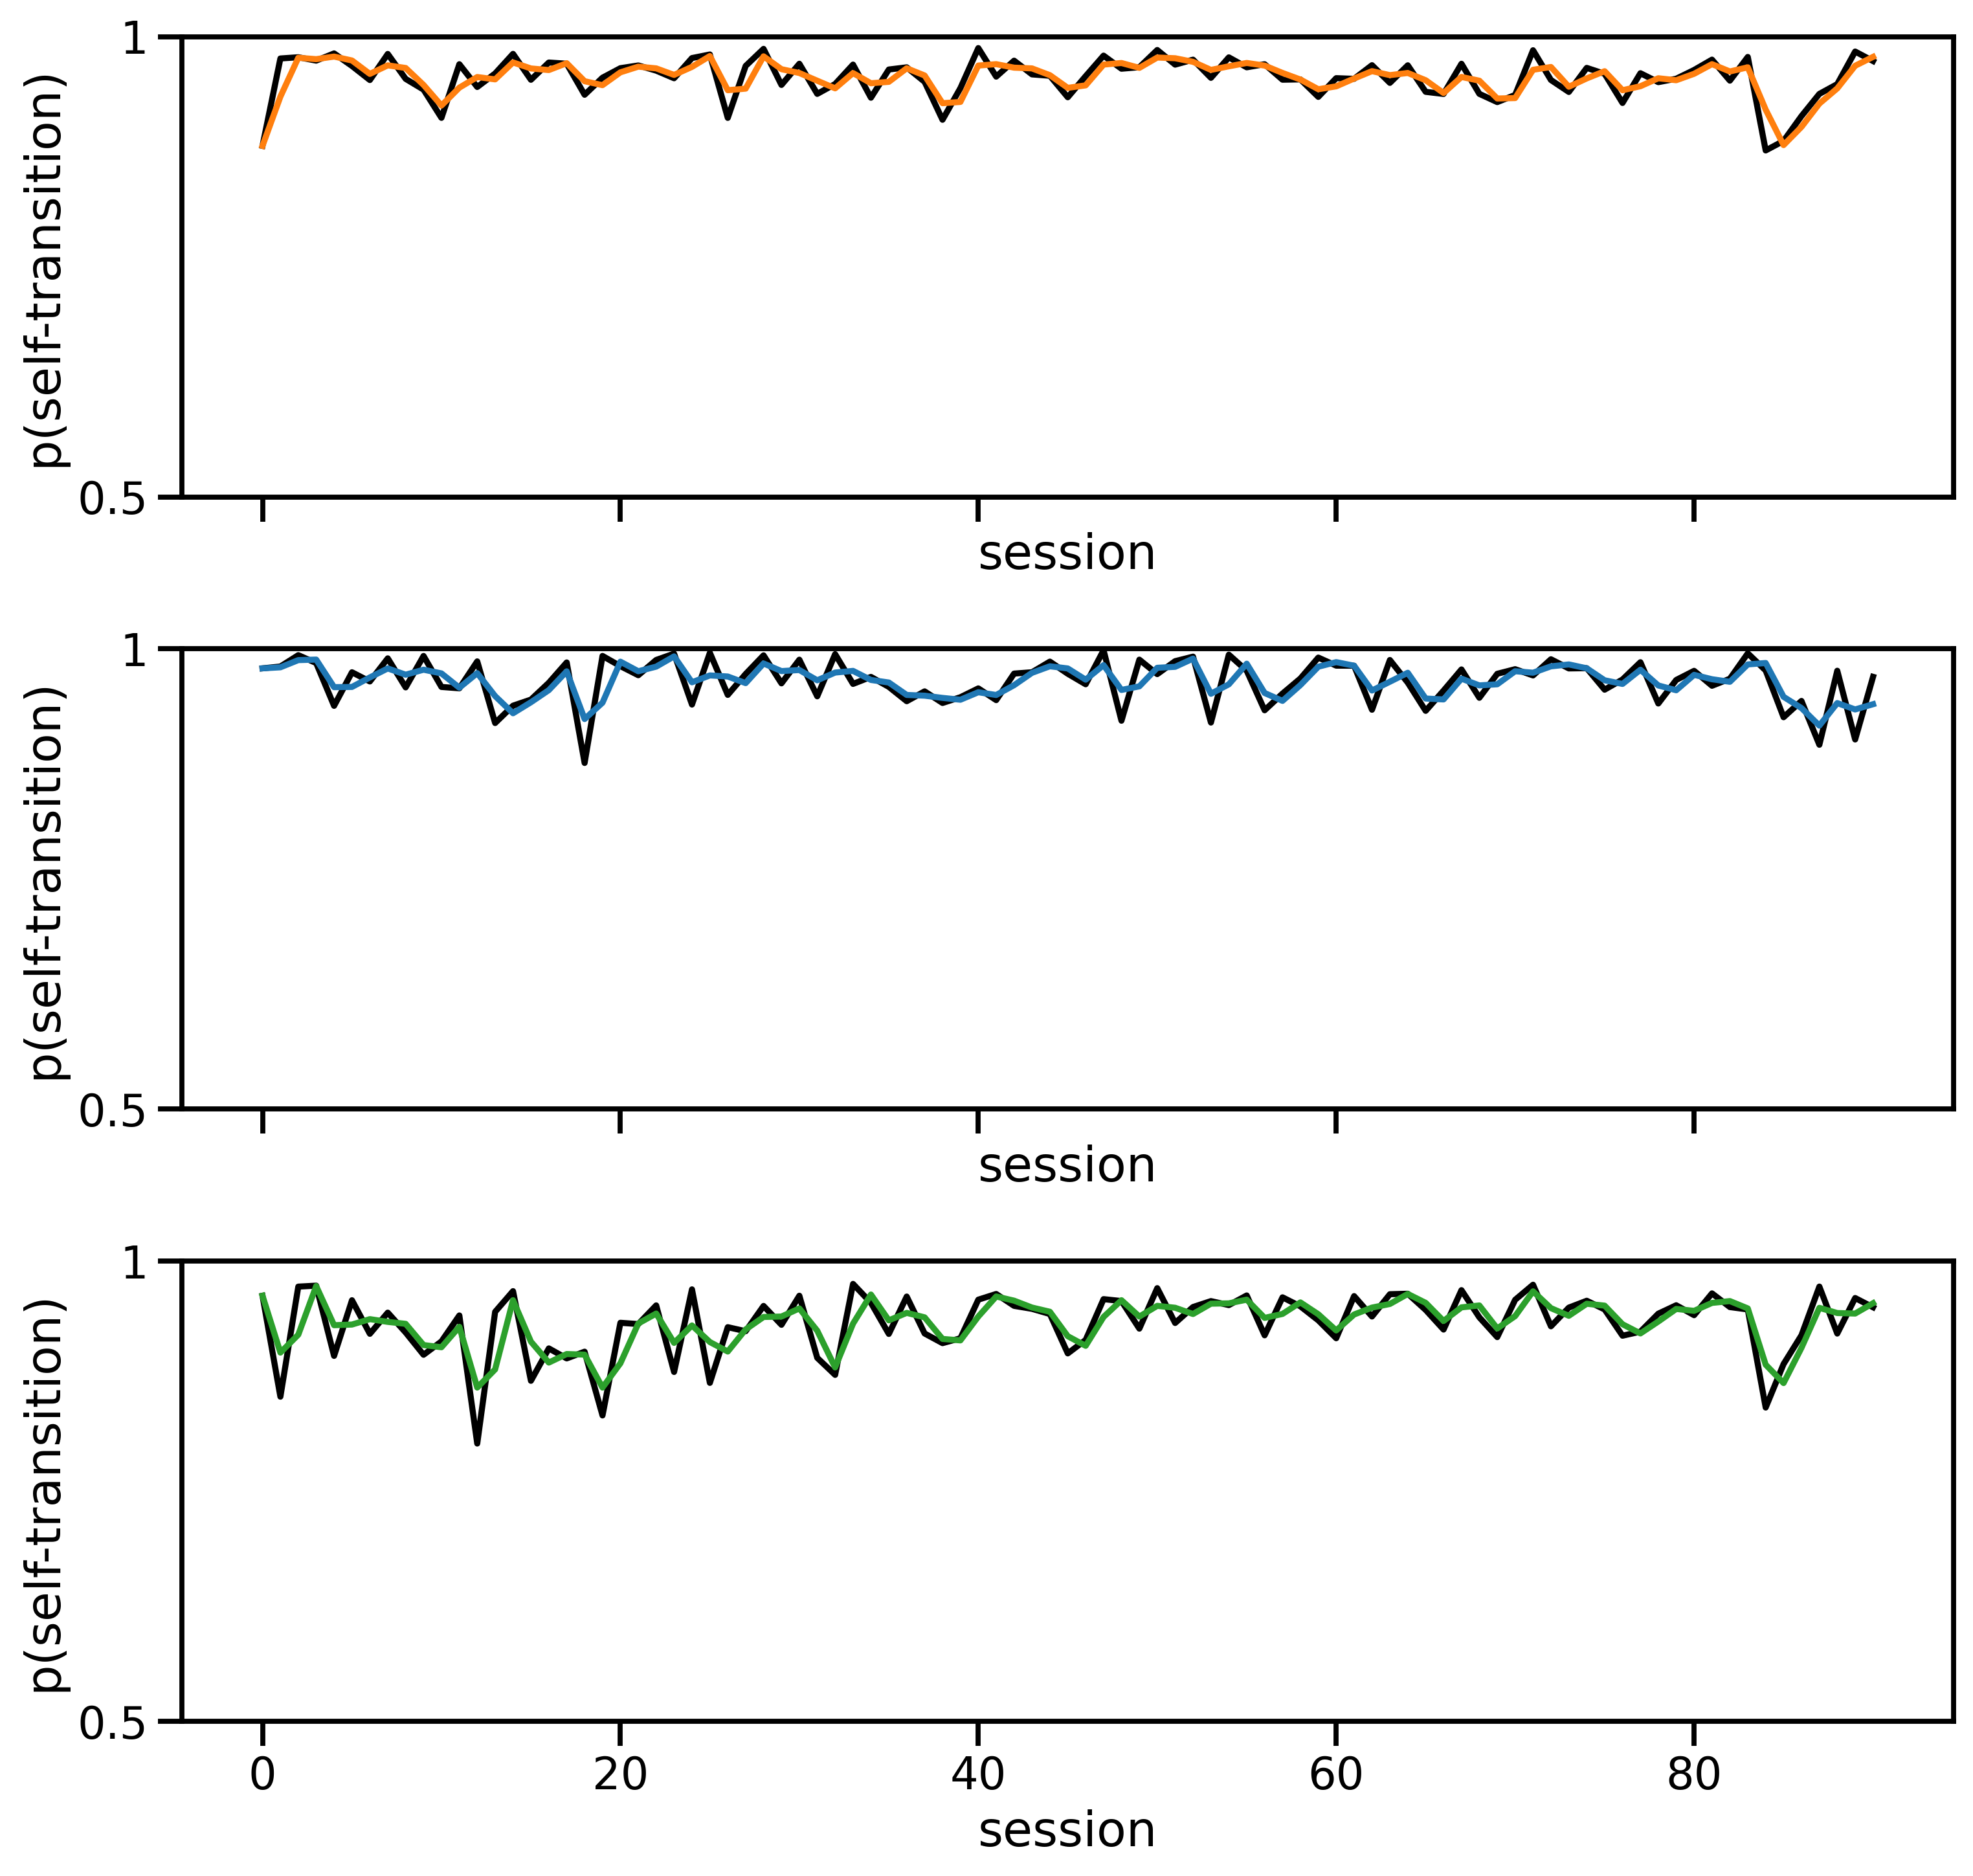

In [31]:
subject='ibl_witten_12'
print(subject)
x, y, sessInd, correctSide, _ = get_mouse_design(dfAll, subject, sessStop=sessStop, signedStimulus=signedStimulus, pTanh=pTanh)
N = x.shape[0]
sess = len(sessInd)-1
prsentAll = np.ones((N)).astype(int)

dGLM_HMM = dynamic_glmhmm.dynamic_GLMHMM(N,K,D,2)

# parameters for best dynamic model
P_fold = np.empty((splitFolds), dtype=object)
W_fold = np.empty((splitFolds), dtype=object)
for fold in range(splitFolds):
    data_dynamic = np.load(f'../data_IBL/{subject}/{subject}_dynamicGLMHMM_CV_{K}-state_fold={fold}_pTanh={pTanh}_L2penaltyW={L2penaltyW}_signedStimulus={signedStimulus}.npz')
    P_fold[fold] = data_dynamic['allP']
    W_fold[fold] = data_dynamic['allW']
allW_best_dynamic, allP_best_dynamic = reshape_parameters_session_to_trials(np.mean(W_fold, axis=0)[bestAlphaInd], np.mean(P_fold, axis=0)[bestAlphaInd], sessInd)

smooth = smoothList[2]
 # smooth with Gaussian Kernel (keeps distributions)
smoothedP = gaussian_filter1d(allP_best_dynamic, sigma=smooth, axis=0)

fig, axes = plt.subplots(3, 1, figsize = (10.5,10), dpi=300, sharex=True)
for k in range(K):
    axes[k].plot(allP_best_dynamic[sessInd[:-1],k,k], color='black')
    axes[k].plot(smoothedP[sessInd[:-1],k,k], color=colorsStates[k], label=f'state {k+1}')
    axes[k].set_ylim(0.5,1)
    axes[k].set_yticks([0.5,1],[0.5,1])
    axes[k].set_ylabel('p(self-transition)')
    axes[k].set_xlabel('session')
# axes.set_title('example best smoothing (sigma=10)')
    
fig.tight_layout()


[-0.0753567  -0.0753567  -0.07535594 -0.07535629 -0.07536862 -0.07541751]
[0, np.float64(1.0), np.float64(3.1622776601683795), np.float64(10.0), np.float64(31.622776601683793), np.float64(100.0)]
[  0.           1.           3.16227766  10.          31.6227766
 100.        ]


Text(0.5, 1.0, 'Average across all animals and 5-folds')

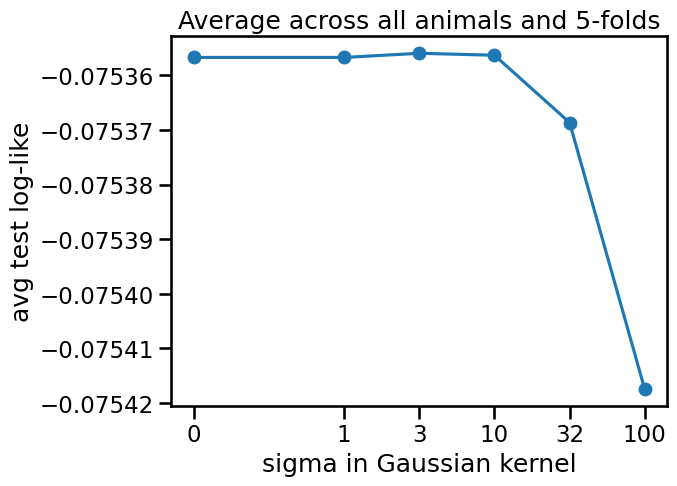

In [10]:
# print(testLL[0])
print(LL[:,:].mean(axis=(0,1)))
# testLL = np.zeros((len(subjectsAll), splitFolds, len(smoothList)))
smoothList =[0] + [10**x for x in np.arange(0,2.5,0.5)]
fig, axes = plt.subplots()
smoothList[0] += 10**(-1)
axes.plot(np.log10(smoothList), LL[:,:].mean(axis=(1)), '-o')
smoothList2 = smoothList.copy()
smoothList2[0] = 0
print(smoothList2)
print(np.array(smoothList2))
axes.set_xticks(np.log10(smoothList), list(np.round(np.array(smoothList2),0).astype(int)))
axes.set_xlabel('sigma in Gaussian kernel')
axes.set_ylabel('avg test log-like')
axes.set_title('Average across all animals and 5-folds')

[0, np.float64(1.0), np.float64(3.1622776601683795), np.float64(10.0), np.float64(31.622776601683793), np.float64(100.0)]
[  0.           1.           3.16227766  10.          31.6227766
 100.        ]


Text(0.5, 1.0, 'Average across all animals and 5-folds')

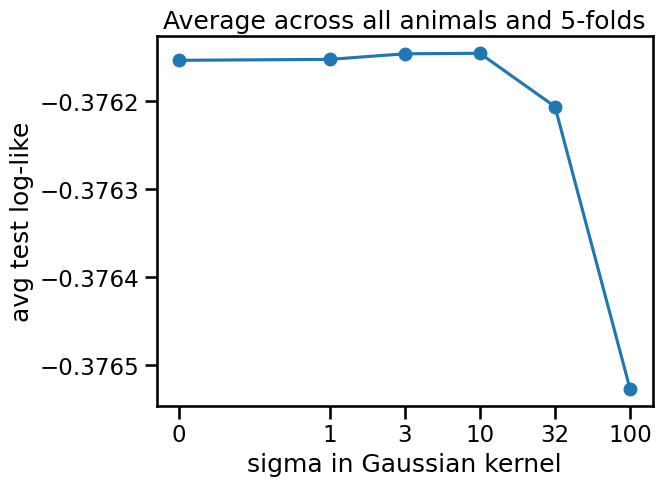

In [43]:
# print(testLL[0])

# testLL = np.zeros((len(subjectsAll), splitFolds, len(smoothList)))
smoothList =[0] + [10**x for x in np.arange(0,2.5,0.5)]
fig, axes = plt.subplots()
smoothList[0] += 10**(-1)
axes.plot(np.log10(smoothList), testLL[:,:].mean(axis=(0,1)), '-o')
smoothList2 = smoothList.copy()
smoothList2[0] = 0
print(smoothList2)
print(np.array(smoothList2))
axes.set_xticks(np.log10(smoothList), list(np.round(np.array(smoothList2),0).astype(int)))
axes.set_xlabel('sigma in Gaussian kernel')
axes.set_ylabel('avg test log-like')
axes.set_title('Average across all animals and 5-folds')